# Install Dependencies

In [20]:
!pip install xgboost optuna scikit-learn matplotlib

# Imports

In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings

# Suppress warnings and Optuna's trial logs for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# Load & Inspect Data

In [22]:
def load_and_preprocess_data():
    """Loads the preprocessed COMPAS dataset and prepares train/test splits."""
    try:
        df = pd.read_csv('/kaggle/input/datasets/thearyanmishra/compas-recidivism/compas_data.csv')
    except FileNotFoundError:
        print("Error: 'compas_data-2.csv' not found. Please ensure it is uploaded to your Kaggle input directory.")
        return None, None, None, None, None

    target = 'Two_yr_Recidivism'
    features = [c for c in df.columns if c != target]
    
    X = df[features]
    y = df[target]
    
    # 80-20 Stratified Split
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # We define African_American as the sensitive attribute (1=African American, 0=Others)
    sensitive_attribute_test = X_test['African_American'].copy()
    
    return X_train_full, y_train_full, X_test, y_test, sensitive_attribute_test

X_train_full, y_train_full, X_test, y_test, sensitive_test = load_and_preprocess_data()
print(f"Data loaded: {X_train_full.shape[0]} train samples, {X_test.shape[0]} test samples.")

Data loaded: 4937 train samples, 1235 test samples.


In [23]:
df = pd.read_csv('/kaggle/input/datasets/thearyanmishra/compas-recidivism/compas_data.csv')  
#df = pd.read_csv('compas_data.csv')

print("Shape:", df.shape)
print("\nClass balance:")
print(df['Two_yr_Recidivism'].value_counts())
print("\nProtected attribute (African_American):")
print(df['African_American'].value_counts())
df.head()

Shape: (6172, 12)

Class balance:
Two_yr_Recidivism
0    3363
1    2809
Name: count, dtype: int64

Protected attribute (African_American):
African_American
1    3175
0    2997
Name: count, dtype: int64


,Two_yr_Recidivism,Number_of_Priors,score_factor,Age_Above_FourtyFive,Age_Below_TwentyFive,African_American,Asian,Hispanic,Native_American,Other,Female,Misdemeanor
0,0,0,0,1,0,0,0,0,0,1,0,0
1,1,0,0,0,0,1,0,0,0,0,0,0
2,1,4,0,0,1,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,1
4,1,14,1,0,0,0,0,0,0,0,0,0


# Fairness Metric Functions

In [24]:
def demographic_parity_difference(y_true, y_pred, sensitive_features):
    """Calculates Demographic Parity Difference (DPD). Lower is better."""
    if not isinstance(sensitive_features, pd.Series):
        sensitive_features = pd.Series(sensitive_features)
    
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'sensitive': sensitive_features.values})
    
    unprivileged = df[df['sensitive'] == 1]
    privileged = df[df['sensitive'] == 0]
    
    ppr_unprivileged = 0.0
    if not unprivileged.empty:
        ppr_unprivileged = unprivileged[unprivileged['pred'] == 1].shape[0] / unprivileged.shape[0]
        
    ppr_privileged = 0.0
    if not privileged.empty:
        ppr_privileged = privileged[privileged['pred'] == 1].shape[0] / privileged.shape[0]
        
    return abs(ppr_unprivileged - ppr_privileged)

def calculate_complexity(params):
    """Proxy for XGBoost tree complexity."""
    n_est = params.get('n_estimators')
    max_d = params.get('max_depth')
    
    # Safely handle None values from XGBoost default initialization
    n_est = n_est if n_est is not None else 100
    max_d = max_d if max_d is not None else 6 # XGBoost default depth is 6
    
    return n_est * max_d

# Maximum theoretical complexity to normalize the complexity metric (200 trees * max depth 8)
MAX_COMPLEXITY = 200 * 8 

# Globals for the iterative weights
current_alpha = 0.0
current_beta = 0.0

print("Fairness metrics defined.")

Fairness metrics defined.


# Optuna Objective Function

In [25]:
def objective_nsga(trial, X_train_opt, y_train_opt, X_val_opt, y_val_opt, sensitive_val_opt):
    
    # 1. Suggest parameters
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': trial.suggest_int('n_estimators', 10, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42
    }
    
    # 2. Train Model
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_opt, y_train_opt, verbose=False)
    
    # 3. Predict on Validation Set
    preds_proba_val = model.predict_proba(X_val_opt)[:, 1]
    preds_binary_val = (preds_proba_val >= 0.5).astype(int)
    
    # 4. Calculate the 3 Raw Objectives
    auc_val = roc_auc_score(y_val_opt, preds_proba_val)
    dpd_val = demographic_parity_difference(y_val_opt, preds_binary_val, sensitive_val_opt)
    complexity_raw = calculate_complexity(params)
    
    # 5. CRUCIAL FIX: Return a tuple of exactly 3 values for NSGA-II 
    # Optuna is configured as: ['maximize' (AUC), 'minimize' (DPD), 'minimize' (Complexity)]
    return auc_val, dpd_val, complexity_raw

print("NSGA-II Objective function fixed for 3 objectives!")

NSGA-II Objective function fixed for 3 objectives!


# 3-D Pareto Filtering & Main Loop 

In [26]:
# --- Filter for Non-Dominated Points (3D with Epsilon) ---
'''def filter_non_dominated(points):
    if not points:
        return []
    
    non_dominated_points = []
    for i, p_i in enumerate(points):
        is_dominated = False
        for j, p_j in enumerate(points):
            if i == j:
                continue
            
            # Extract metrics for point i and point j
            auc_i, dpd_i, comp_i = p_i['auc'], p_i['dpd'], p_i['complexity']
            auc_j, dpd_j, comp_j = p_j['auc'], p_j['dpd'], p_j['complexity']
            
            epsilon = 1e-9
            
            # Condition 1: j is better than or equal to i in ALL dimensions
            # (Maximize AUC, Minimize DPD, Minimize Complexity)
            is_better_or_equal = (
                auc_j >= auc_i - epsilon and 
                dpd_j <= dpd_i + epsilon and 
                comp_j <= comp_i + epsilon
            )
            
            # Condition 2: j is strictly better than i in AT LEAST ONE dimension
            is_strictly_better = (
                auc_j > auc_i + epsilon or 
                dpd_j < dpd_i - epsilon or 
                comp_j < comp_i - epsilon
            )
            
            # If both are true, point j dominates point i
            if is_better_or_equal and is_strictly_better:
                is_dominated = True
                break
                
        if not is_dominated:
            non_dominated_points.append(p_i)
            
    return non_dominated_points

def execute_weighted_pareto_search(n_optuna_trials=50, step_size=0.2):
    global current_alpha, current_beta
    
    # Create internal validation set for Optuna to prevent overfitting on the test set
    X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=123, stratify=y_train_full
    )
    sensitive_val_opt = X_val_opt['African_American']
    
    candidate_points = []
    
    # Create grid of weights where alpha + beta <= 1.0
    alphas = np.arange(0.0, 1.01, step_size)
    betas = np.arange(0.0, 1.01, step_size)
    weight_pairs = [(a, b) for a in alphas for b in betas if (a + b) <= 1.0001] # 1.0001 for float precision
    
    print(f"Total weight combinations to test: {len(weight_pairs)}")
    
    for (alpha, beta) in weight_pairs:
        current_alpha = alpha
        current_beta = beta
        gamma = 1.0 - alpha - beta
        
        # Prevent floating point negative zeros
        if gamma < 0: gamma = 0.0 
        
        print(f"\nEvaluating Weights -> α(AUC): {alpha:.2f}, β(DPD): {beta:.2f}, γ(Comp): {gamma:.2f}")
        
        study = optuna.create_study(direction='minimize')
        study.optimize(
            lambda trial: objective(trial, X_train_opt, y_train_opt, X_val_opt, y_val_opt, sensitive_val_opt),
            n_trials=n_optuna_trials
        )
        
        best_params = study.best_params
        
        # Retrain on the full training set and evaluate on the true, unseen TEST set
        final_model = xgb.XGBClassifier(**best_params, objective='binary:logistic', random_state=42)
        final_model.fit(X_train_full, y_train_full, verbose=False)
        
        preds_proba_test = final_model.predict_proba(X_test)[:, 1]
        preds_binary_test = (preds_proba_test >= 0.5).astype(int)
        
        auc_test = roc_auc_score(y_test, preds_proba_test)
        dpd_test = demographic_parity_difference(y_test, preds_binary_test, sensitive_test)
        complexity_test = calculate_complexity(best_params)
        
        print(f"Result -> Test AUC: {auc_test:.4f} | Test DPD: {dpd_test:.4f} | Complexity: {complexity_test}")
        
        candidate_points.append({
            'auc': auc_test, 'dpd': dpd_test, 'complexity': complexity_test, 
            'alpha': alpha, 'beta': beta, 'gamma': gamma, 'params': best_params
        })
        
    non_dominated = filter_non_dominated(candidate_points)
    print(f"\nSearch complete. Found {len(non_dominated)} non-dominated points out of {len(candidate_points)} candidates.")
    
    return candidate_points, non_dominated

# Execute search (You can increase n_optuna_trials for better results later)
all_points, pareto_points = execute_weighted_pareto_search(n_optuna_trials=100, step_size=0.1)
'''

'def filter_non_dominated(points):\n    if not points:\n        return []\n    \n    non_dominated_points = []\n    for i, p_i in enumerate(points):\n        is_dominated = False\n        for j, p_j in enumerate(points):\n            if i == j:\n                continue\n            \n            # Extract metrics for point i and point j\n            auc_i, dpd_i, comp_i = p_i[\'auc\'], p_i[\'dpd\'], p_i[\'complexity\']\n            auc_j, dpd_j, comp_j = p_j[\'auc\'], p_j[\'dpd\'], p_j[\'complexity\']\n            \n            epsilon = 1e-9\n            \n            # Condition 1: j is better than or equal to i in ALL dimensions\n            # (Maximize AUC, Minimize DPD, Minimize Complexity)\n            is_better_or_equal = (\n                auc_j >= auc_i - epsilon and \n                dpd_j <= dpd_i + epsilon and \n                comp_j <= comp_i + epsilon\n            )\n            \n            # Condition 2: j is strictly better than i in AT LEAST ONE dimension\n        

In [95]:
def filter_non_dominated(points, eps_auc=0.002, eps_dpd=0.015, eps_comp=25):
    """
    Filters points to find the Pareto front, then applies an Epsilon-sparsity 
    filter to ensure points are visually distinct for presentation/demos.
    """
    if not points:
        return []
        
    # STEP 1: Strict Pareto Dominance (Find the true mathematical front)
    strict_front = []
    for i, p_i in enumerate(points):
        is_dominated = False
        for j, p_j in enumerate(points):
            if i == j: continue
            
            # Maximize AUC, Minimize DPD, Minimize Complexity
            auc_better_eq = p_j['auc'] >= p_i['auc']
            dpd_better_eq = p_j['dpd'] <= p_i['dpd']
            comp_better_eq = p_j['complexity'] <= p_i['complexity']
            
            auc_better = p_j['auc'] > p_i['auc']
            dpd_better = p_j['dpd'] < p_i['dpd']
            comp_better = p_j['complexity'] < p_i['complexity']
            
            if (auc_better_eq and dpd_better_eq and comp_better_eq) and (auc_better or dpd_better or comp_better):
                is_dominated = True
                break
                
        if not is_dominated:
            strict_front.append(p_i)
            
    # STEP 2: Epsilon-Sparsity Pruning for Demo Presentation
    # Sort by AUC descending so we prioritize keeping the absolute highest performers first
    strict_front = sorted(strict_front, key=lambda x: x['auc'], reverse=True)
    demo_front = []
    
    for p_i in strict_front:
        is_too_close = False
        for p_j in demo_front:
            # Check if this point is practically identical (within epsilon) to a point we already kept
            diff_auc = abs(p_i['auc'] - p_j['auc'])
            diff_dpd = abs(p_i['dpd'] - p_j['dpd'])
            diff_comp = abs(p_i['complexity'] - p_j['complexity'])
            
            if diff_auc < eps_auc and diff_dpd < eps_dpd and diff_comp < eps_comp:
                is_too_close = True
                break
                
        if not is_too_close:
            demo_front.append(p_i)
            
    return demo_front

def execute_nsga_optimization_fixed(n_trials=250):
    X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=123, stratify=y_train_full
    )
    sensitive_val_opt = X_val_opt['African_American']
    
    print(f"Starting NSGA-II Optimization ({n_trials} trials)...")
    
    sampler = optuna.samplers.NSGAIISampler(seed=42)
    study = optuna.create_study(directions=['maximize', 'minimize', 'minimize'], sampler=sampler)
    
    study.optimize(
        lambda trial: objective_nsga(trial, X_train_opt, y_train_opt, X_val_opt, y_val_opt, sensitive_val_opt),
        n_trials=n_trials,
        show_progress_bar=True
    )
    
    all_points = []
    
    # Re-evaluate ALL trials on the Test Set
    for trial in study.trials:
        if trial.state != optuna.trial.TrialState.COMPLETE:
            continue
            
        params = trial.params
        model = xgb.XGBClassifier(**params, objective='binary:logistic', random_state=42)
        model.fit(X_train_full, y_train_full, verbose=False)
        
        preds_proba_test = model.predict_proba(X_test)[:, 1]
        preds_binary_test = (preds_proba_test >= 0.5).astype(int)
        
        all_points.append({
            'auc': roc_auc_score(y_test, preds_proba_test),
            'dpd': demographic_parity_difference(y_test, preds_binary_test, sensitive_test),
            'complexity': calculate_complexity(params),
            'params': params
        })
        
    # Crucial Fix: Recalculate the Pareto Front on the TEST set results!
    pareto_points = filter_non_dominated(all_points)
    
    print(f"Found {len(pareto_points)} non-dominated points on the true Test Front.")
    return all_points, pareto_points

all_points, pareto_points = execute_nsga_optimization_fixed(n_trials=800)

Starting NSGA-II Optimization (800 trials)...


  0%|          | 0/800 [00:00<?, ?it/s]

Found 19 non-dominated points on the true Test Front.


# Plotting results: 2D and 3D Pareto Fronts

In [70]:
'''def plot_clean_pareto_frontiers(all_points, pareto_points):
    if not all_points:
        print("No points to plot.")
        return
    
    fig = plt.figure(figsize=(20, 16))
    
    # ---------------------------------------------------------
    # Helper lists for plotting Dominated Points as Gray Crosses
    # ---------------------------------------------------------
    pareto_params_str = {str(p['params']) for p in pareto_points}
    dom_points = [p for p in all_points if str(p['params']) not in pareto_params_str]
    
    dom_aucs = [p['auc'] for p in dom_points]
    dom_dpds = [p['dpd'] for p in dom_points]
    dom_comps = [p['complexity'] for p in dom_points]
    
    # ---------------------------------------------------------
    # Extract Pareto points (No sorting needed without lines)
    # ---------------------------------------------------------
    p_aucs = [p['auc'] for p in pareto_points]
    p_dpds = [p['dpd'] for p in pareto_points]
    p_comps = [p['complexity'] for p in pareto_points]
    p_alphas = [p['alpha'] for p in pareto_points]
    
    # --- 1. AUC vs DPD (2D) ---
    ax1 = fig.add_subplot(221)
    if dom_points:
        ax1.scatter(dom_dpds, dom_aucs, c='gray', marker='x', s=70, alpha=0.5, label='Dominated')
        
    scatter1 = ax1.scatter(p_dpds, p_aucs, c=p_comps, cmap='viridis', s=120, edgecolors='k', alpha=0.9, label='Pareto Front', zorder=5)
    
    ax1.set_xlabel('Demographic Parity Difference (DPD) ↓', fontsize=12)
    ax1.set_ylabel('AUC-ROC ↑', fontsize=12)
    ax1.set_title('Pareto Front: AUC vs DPD', fontsize=14)
    fig.colorbar(scatter1, ax=ax1, label='Model Complexity')
    ax1.legend(loc='best')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # --- 2. AUC vs Complexity (2D) ---
    ax2 = fig.add_subplot(222)
    if dom_points:
        ax2.scatter(dom_comps, dom_aucs, c='gray', marker='x', s=70, alpha=0.5, label='Dominated')
        
    scatter2 = ax2.scatter(p_comps, p_aucs, c=p_dpds, cmap='plasma_r', s=120, edgecolors='k', alpha=0.9, label='Pareto Front', zorder=5)
    
    ax2.set_xlabel('Model Complexity ↓', fontsize=12)
    ax2.set_ylabel('AUC-ROC ↑', fontsize=12)
    ax2.set_title('Pareto Front: AUC vs Complexity', fontsize=14)
    fig.colorbar(scatter2, ax=ax2, label='DPD')
    ax2.legend(loc='best')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # --- 3. DPD vs Complexity (2D) ---
    ax3 = fig.add_subplot(223)
    if dom_points:
        ax3.scatter(dom_comps, dom_dpds, c='gray', marker='x', s=70, alpha=0.5, label='Dominated')
        
    scatter3 = ax3.scatter(p_comps, p_dpds, c=p_aucs, cmap='coolwarm', s=120, edgecolors='k', alpha=0.9, label='Pareto Front', zorder=5)
    
    ax3.set_xlabel('Model Complexity ↓', fontsize=12)
    ax3.set_ylabel('Demographic Parity Difference (DPD) ↓', fontsize=12)
    ax3.set_title('Pareto Front: DPD vs Complexity', fontsize=14)
    fig.colorbar(scatter3, ax=ax3, label='AUC-ROC')
    ax3.legend(loc='best')
    ax3.grid(True, linestyle='--', alpha=0.6)
    
    # --- 4. 3D Pareto Frontier ---
    ax4 = fig.add_subplot(224, projection='3d')
    if dom_points:
        ax4.scatter(dom_dpds, dom_comps, dom_aucs, c='gray', marker='x', s=40, alpha=0.3, label='Dominated')
        
    # In 3D, the points form a visible surface structure!
    scatter4 = ax4.scatter(p_dpds, p_comps, p_aucs, c=p_alphas, cmap='Set1', s=120, edgecolors='k', alpha=0.9, label='Pareto Front')
    
    ax4.set_xlabel('DPD ↓ (Fairness)', fontsize=11)
    ax4.set_ylabel('Complexity ↓', fontsize=11)
    ax4.set_zlabel('AUC-ROC ↑ (Performance)', fontsize=11)
    ax4.set_title('3D Non-Dominated Frontier', fontsize=14)
    ax4.legend(loc='upper right')
    
    # Set view angle for better 3D visibility
    ax4.view_init(elev=20, azim=135)
    
    plt.tight_layout(pad=4.0)
    plt.show()

# Run the plot
plot_clean_pareto_frontiers(all_points, pareto_points)'''

'def plot_clean_pareto_frontiers(all_points, pareto_points):\n    if not all_points:\n        print("No points to plot.")\n        return\n    \n    fig = plt.figure(figsize=(20, 16))\n    \n    # ---------------------------------------------------------\n    # Helper lists for plotting Dominated Points as Gray Crosses\n    # ---------------------------------------------------------\n    pareto_params_str = {str(p[\'params\']) for p in pareto_points}\n    dom_points = [p for p in all_points if str(p[\'params\']) not in pareto_params_str]\n    \n    dom_aucs = [p[\'auc\'] for p in dom_points]\n    dom_dpds = [p[\'dpd\'] for p in dom_points]\n    dom_comps = [p[\'complexity\'] for p in dom_points]\n    \n    # ---------------------------------------------------------\n    # Extract Pareto points (No sorting needed without lines)\n    # ---------------------------------------------------------\n    p_aucs = [p[\'auc\'] for p in pareto_points]\n    p_dpds = [p[\'dpd\'] for p in pareto_poin

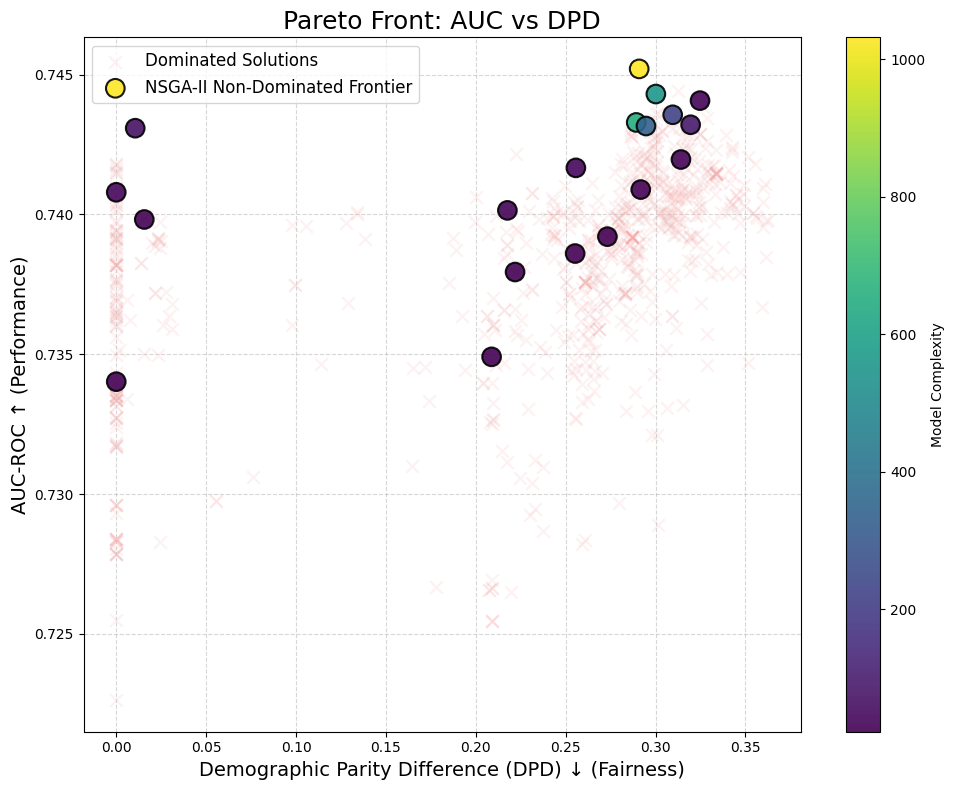

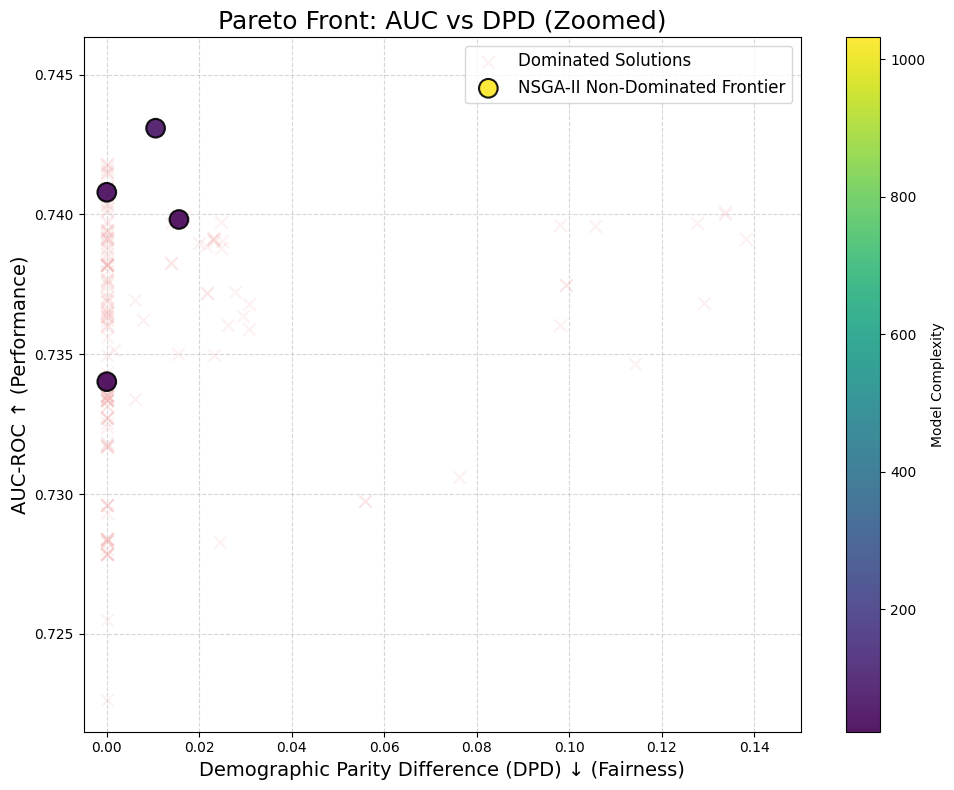

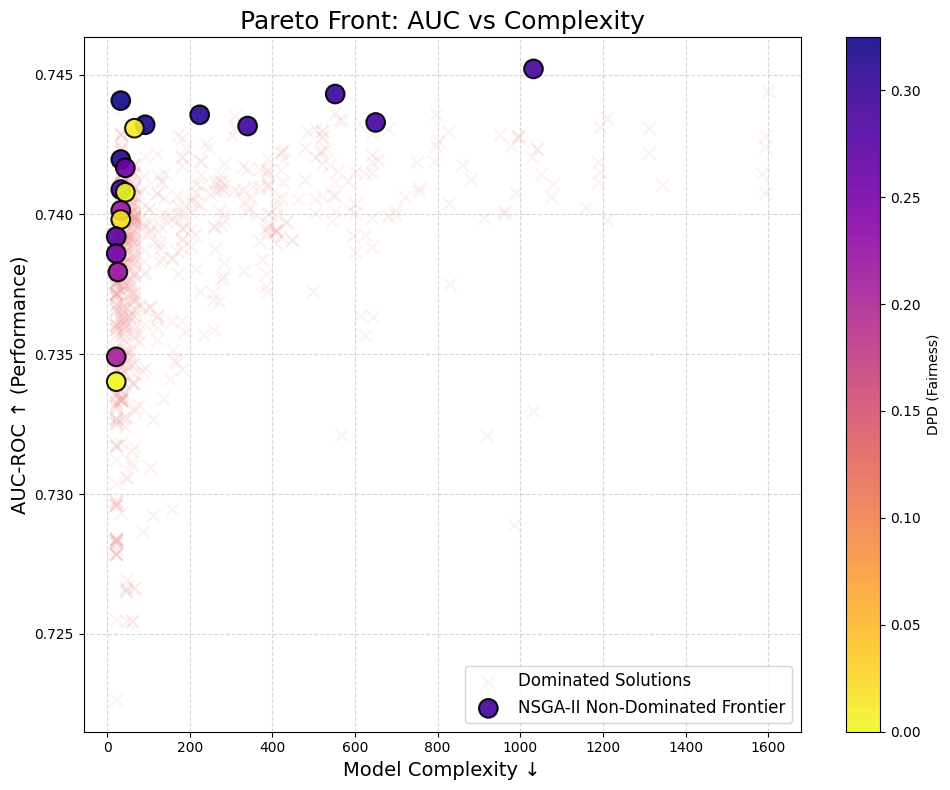

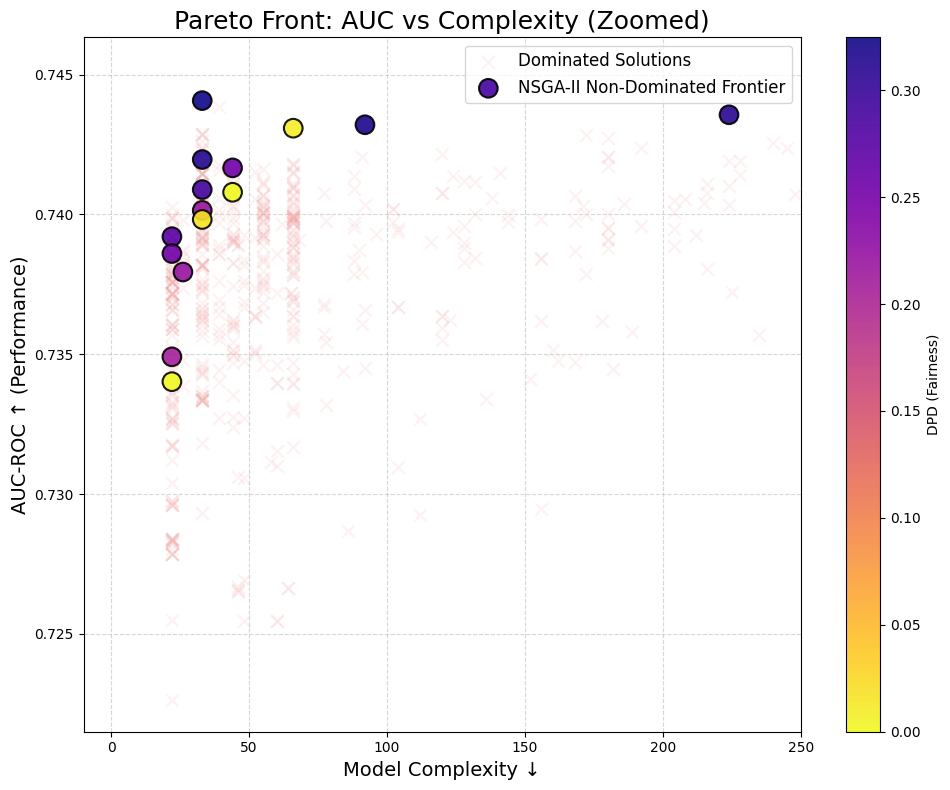

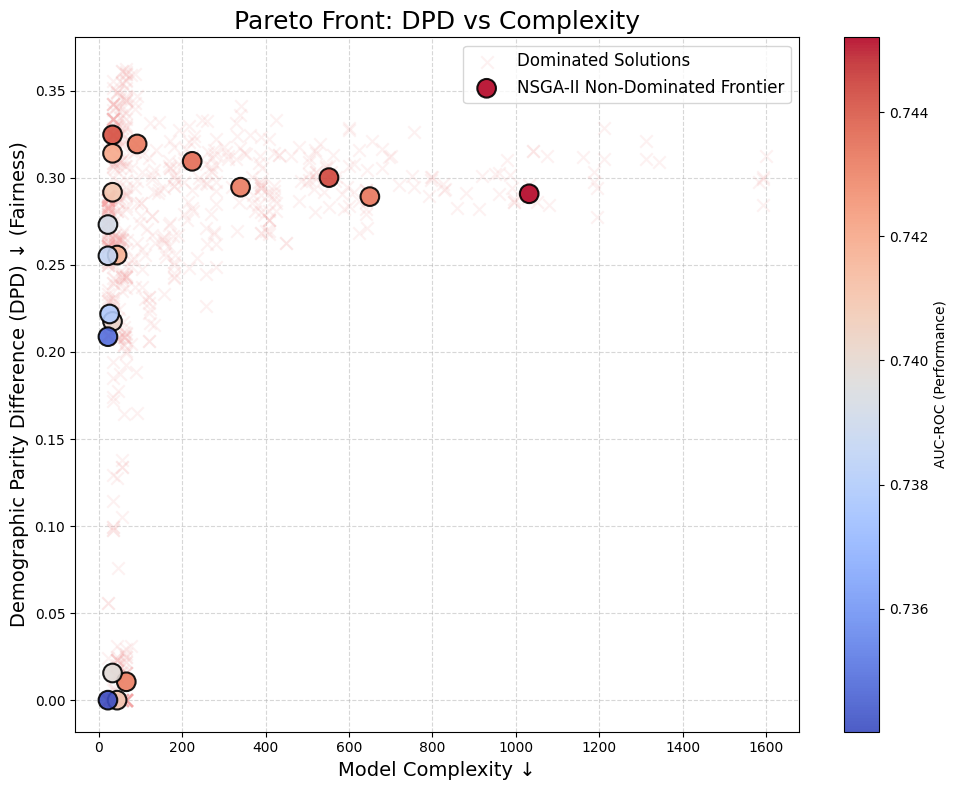

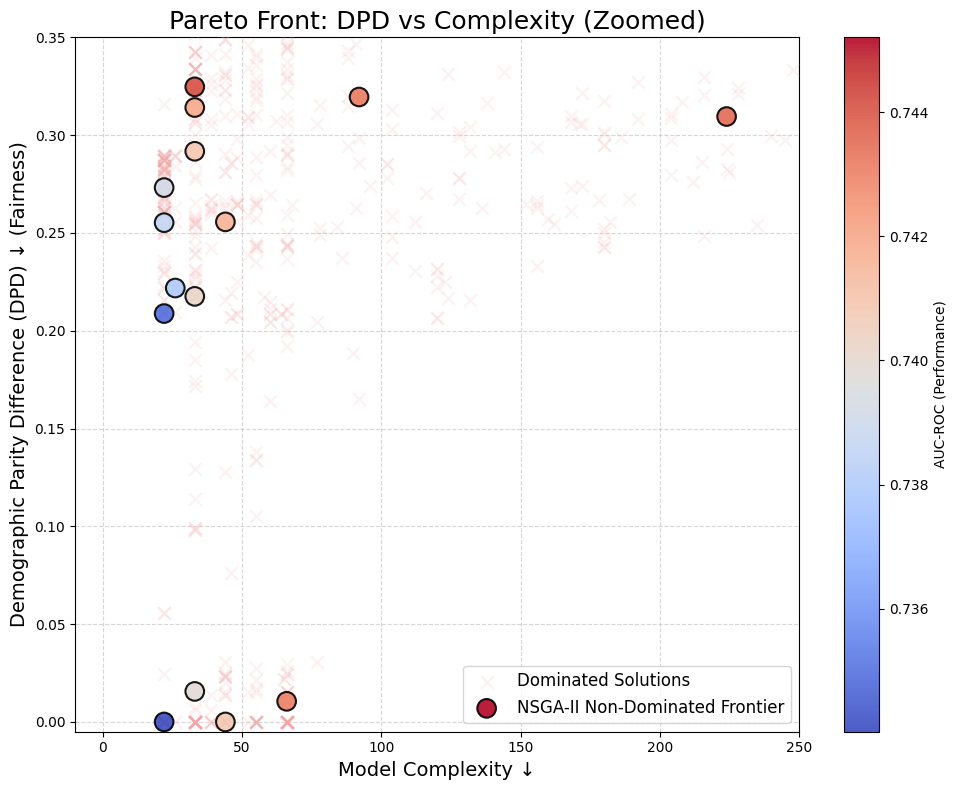

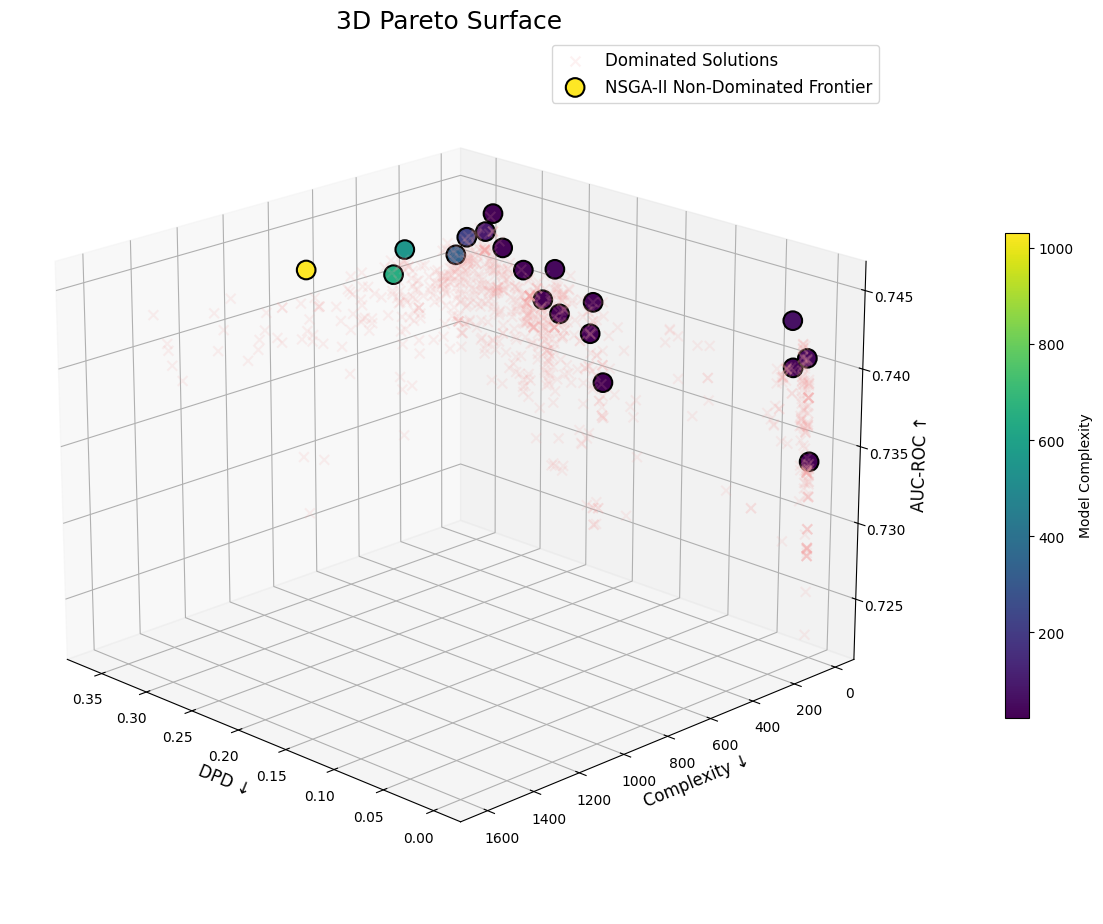

In [96]:
def plot_separate_nsga_frontiers(all_points, pareto_points):
    if not all_points:
        return
    
    # ---------------------------------------------------------
    # Prepare Data
    # ---------------------------------------------------------
    pareto_ids = {str(p['params']) for p in pareto_points}
    dom_points = [p for p in all_points if str(p['params']) not in pareto_ids]
    
    d_aucs = [p['auc'] for p in dom_points]
    d_dpds = [p['dpd'] for p in dom_points]
    d_comps = [p['complexity'] for p in dom_points]
    
    p_aucs = [p['auc'] for p in pareto_points]
    p_dpds = [p['dpd'] for p in pareto_points]
    p_comps = [p['complexity'] for p in pareto_points]
    
    p_alphas = np.linspace(0.1, 1.0, len(p_aucs)) 
    
    dom_color = '#f4a6a6'
    dom_alpha = 0.15

    # Helper function to generate 2D plots
    def make_2d_plot(x_dom, y_dom, x_par, y_par, c_par, cmap_par, cbar_label, xlabel, ylabel, title, zoom_limits=None):
        plt.figure(figsize=(10, 8))
        # Dominated points
        plt.scatter(x_dom, y_dom, c=dom_color, marker='x', s=80, alpha=dom_alpha, label='Dominated Solutions', zorder=3)
        # Pareto points
        scatter = plt.scatter(x_par, y_par, c=c_par, cmap=cmap_par, s=180, edgecolors='black', linewidth=1.5, alpha=0.9, label='NSGA-II Non-Dominated Frontier', zorder=5)
        
        if zoom_limits:
            if 'x' in zoom_limits: plt.xlim(zoom_limits['x'])
            if 'y' in zoom_limits: plt.ylim(zoom_limits['y'])
            title += " (Zoomed)"
            
        plt.xlabel(xlabel, fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        plt.title(title, fontsize=18)
        plt.colorbar(scatter, label=cbar_label)
        plt.legend(loc='best', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    # ==========================================
    # Plot 1: AUC vs DPD (Normal & Zoomed)
    # ==========================================
    make_2d_plot(d_dpds, d_aucs, p_dpds, p_aucs, p_comps, 'viridis', 'Model Complexity', 
                 'Demographic Parity Difference (DPD) ↓ (Fairness)', 'AUC-ROC ↑ (Performance)', 'Pareto Front: AUC vs DPD')
                 
    make_2d_plot(d_dpds, d_aucs, p_dpds, p_aucs, p_comps, 'viridis', 'Model Complexity', 
                 'Demographic Parity Difference (DPD) ↓ (Fairness)', 'AUC-ROC ↑ (Performance)', 'Pareto Front: AUC vs DPD',
                 zoom_limits={'x': (-0.005, 0.15)})

    # ==========================================
    # Plot 2: AUC vs Complexity (Normal & Zoomed)
    # ==========================================
    make_2d_plot(d_comps, d_aucs, p_comps, p_aucs, p_dpds, 'plasma_r', 'DPD (Fairness)', 
                 'Model Complexity ↓', 'AUC-ROC ↑ (Performance)', 'Pareto Front: AUC vs Complexity')

    make_2d_plot(d_comps, d_aucs, p_comps, p_aucs, p_dpds, 'plasma_r', 'DPD (Fairness)', 
                 'Model Complexity ↓', 'AUC-ROC ↑ (Performance)', 'Pareto Front: AUC vs Complexity',
                 zoom_limits={'x': (-10, 250)})

    # ==========================================
    # Plot 3: DPD vs Complexity (Normal & Zoomed)
    # ==========================================
    make_2d_plot(d_comps, d_dpds, p_comps, p_dpds, p_aucs, 'coolwarm', 'AUC-ROC (Performance)', 
                 'Model Complexity ↓', 'Demographic Parity Difference (DPD) ↓ (Fairness)', 'Pareto Front: DPD vs Complexity')

    make_2d_plot(d_comps, d_dpds, p_comps, p_dpds, p_aucs, 'coolwarm', 'AUC-ROC (Performance)', 
                 'Model Complexity ↓', 'Demographic Parity Difference (DPD) ↓ (Fairness)', 'Pareto Front: DPD vs Complexity',
                 zoom_limits={'x': (-10, 250), 'y': (-0.005, 0.35)})

    # ==========================================
    # Plot 4: 3D Visualization (Normal)
    # ==========================================
    fig4 = plt.figure(figsize=(12, 10))
    ax4 = fig4.add_subplot(111, projection='3d')
    ax4.scatter(d_dpds, d_comps, d_aucs, c=dom_color, marker='x', s=50, alpha=dom_alpha, label='Dominated Solutions')
    scatter4 = ax4.scatter(p_dpds, p_comps, p_aucs, c=p_comps, cmap='viridis', s=180, edgecolors='black', linewidth=1.5, alpha=1.0, label='NSGA-II Non-Dominated Frontier', zorder=5)

    fig4.colorbar(scatter4, ax=ax4, label='Model Complexity', shrink=0.5, pad=0.1)
    
    ax4.set_xlabel('DPD ↓', fontsize=12)
    ax4.set_ylabel('Complexity ↓', fontsize=12)
    ax4.set_zlabel('AUC-ROC ↑', fontsize=12)
    ax4.set_title('3D Pareto Surface', fontsize=18)
    ax4.legend(loc='upper right', fontsize=12)
    ax4.view_init(elev=20, azim=135)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 5: 3D Visualization (Zoomed)
    # ==========================================
    '''fig5 = plt.figure(figsize=(12, 10))
    ax5 = fig5.add_subplot(111, projection='3d')
    ax5.scatter(d_dpds, d_comps, d_aucs, c=dom_color, marker='x', s=50, alpha=dom_alpha, label='Dominated Solutions')
    scatter5 = ax5.scatter(p_dpds, p_comps, p_aucs, c=p_comps, cmap='viridis', s=180, edgecolors='black', linewidth=1.5, alpha=1.0, label='NSGA-II Non-Dominated Frontier', zorder=5)

    fig5.colorbar(scatter5, ax=ax5, label='Model Complexity', shrink=0.5, pad=0.1)
    
    ax5.set_xlim(-0.005, 0.10)  # Zoom DPD
    ax5.set_ylim(-10, 300)      # Zoom Complexity
    ax5.set_xlabel('DPD ↓', fontsize=12)
    ax5.set_ylabel('Complexity ↓', fontsize=12)
    ax5.set_zlabel('AUC-ROC ↑', fontsize=12)
    ax5.set_title('3D Pareto Surface (Zoomed)', fontsize=18)
    ax5.legend(loc='upper right', fontsize=12)
    ax5.view_init(elev=20, azim=135)
    plt.tight_layout()
    plt.show()
    '''

# Run the plotting function
plot_separate_nsga_frontiers(all_points, pareto_points)

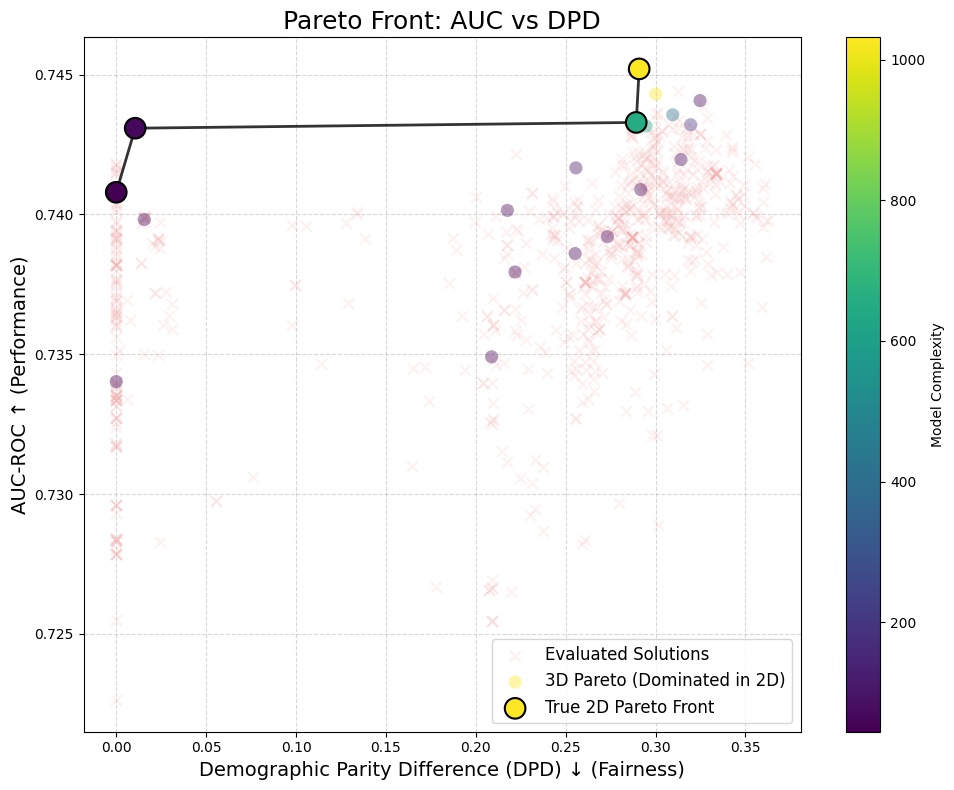

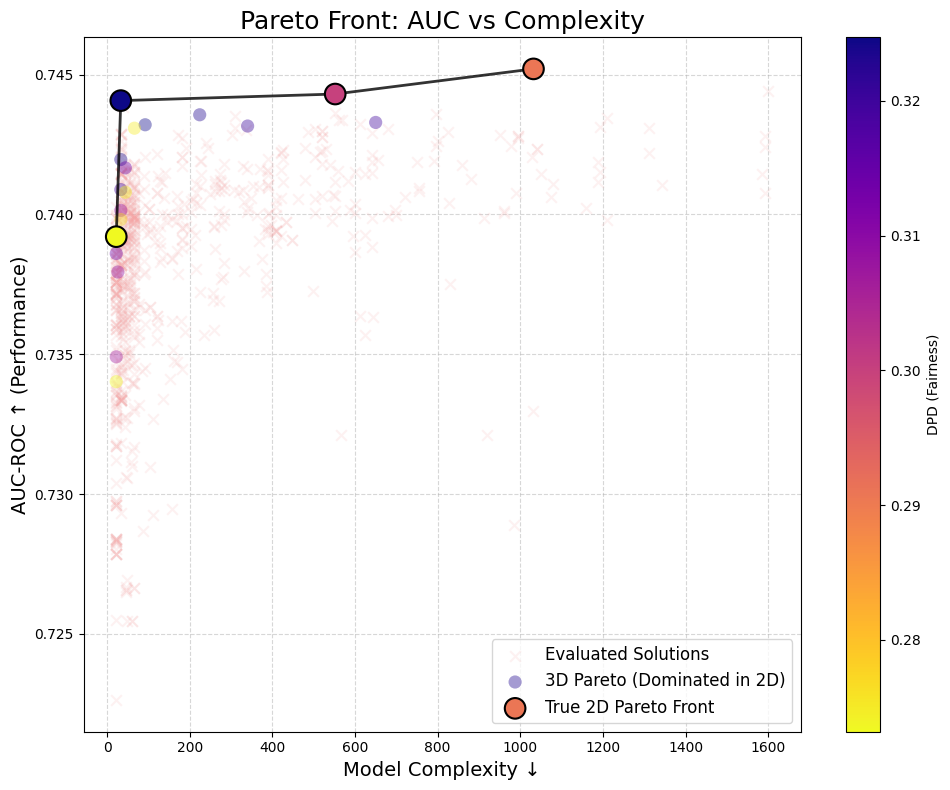

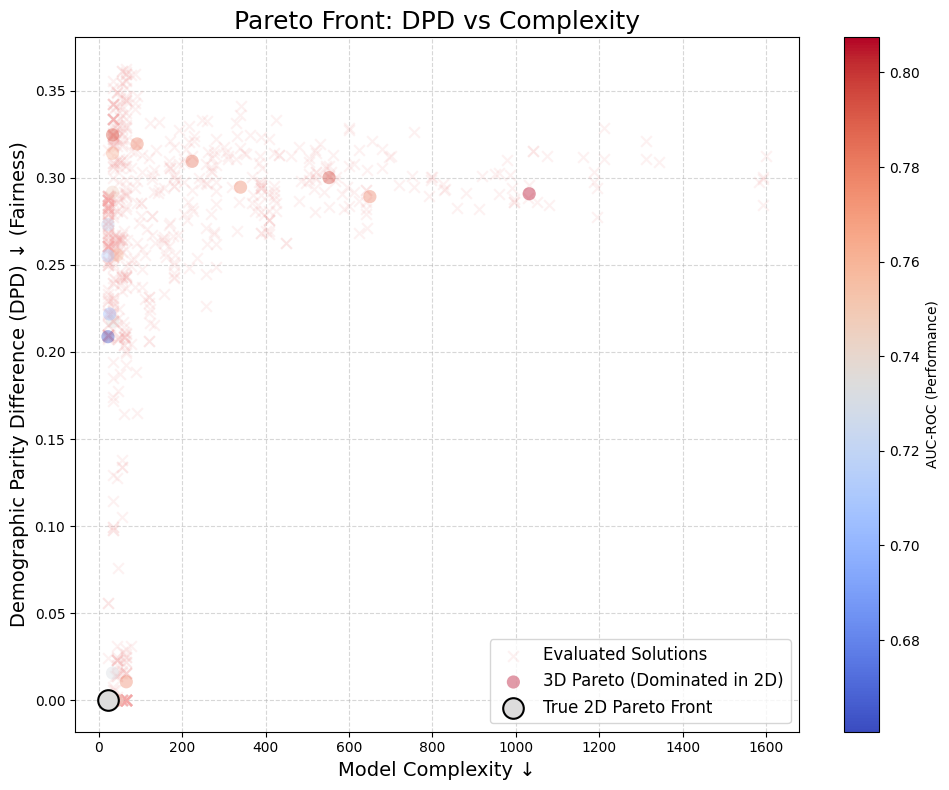

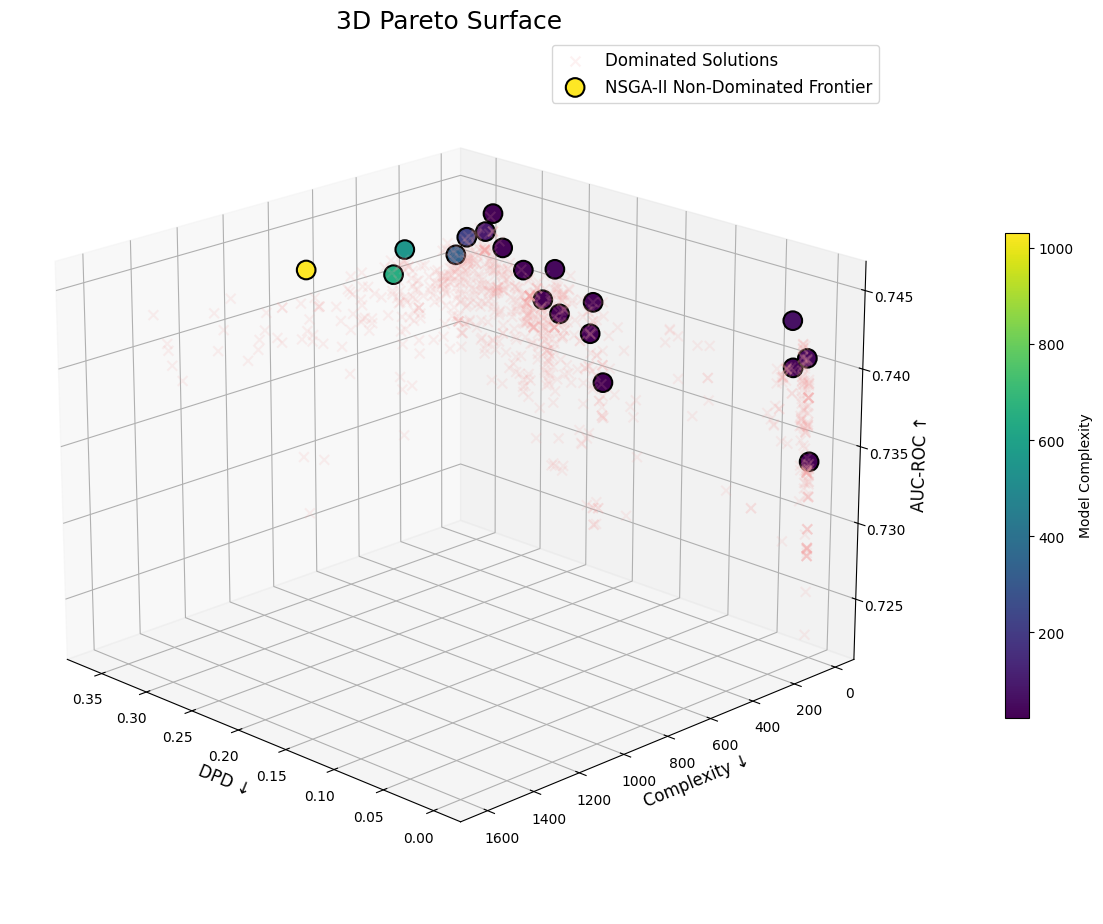

In [97]:
import numpy as np
import matplotlib.pyplot as plt

def plot_layered_nsga_frontiers(all_points, pareto_points):
    if not all_points:
        return
    
    # ---------------------------------------------------------
    # Prepare Data
    # ---------------------------------------------------------
    pareto_ids = {str(p['params']) for p in pareto_points}
    dom_points = [p for p in all_points if str(p['params']) not in pareto_ids]
    
    d_aucs = [p['auc'] for p in dom_points]
    d_dpds = [p['dpd'] for p in dom_points]
    d_comps = [p['complexity'] for p in dom_points]
    
    p_aucs = [p['auc'] for p in pareto_points]
    p_dpds = [p['dpd'] for p in pareto_points]
    p_comps = [p['complexity'] for p in pareto_points]
    
    dom_color = '#f4a6a6'
    dom_alpha = 0.15

    # ---------------------------------------------------------
    # 2D Pareto Filter
    # ---------------------------------------------------------
    def get_2d_pareto(xs, ys, min_x=True, min_y=False):
        pareto_idx = []
        for i in range(len(xs)):
            is_dominated = False
            for j in range(len(xs)):
                if i == j: continue
                better_x = xs[j] < xs[i] if min_x else xs[j] > xs[i]
                eq_x = xs[j] == xs[i]
                better_y = ys[j] < ys[i] if min_y else ys[j] > ys[i]
                eq_y = ys[j] == ys[i]
                
                if (better_x or eq_x) and (better_y or eq_y) and (better_x or better_y):
                    is_dominated = True
                    break
            if not is_dominated:
                pareto_idx.append(i)
        return pareto_idx

    # ---------------------------------------------------------
    # Helper function to generate Layered 2D plots
    # ---------------------------------------------------------
    def make_2d_layered_plot(x_dom, y_dom, x_par, y_par, c_par, min_x, min_y, cmap_par, cbar_label, xlabel, ylabel, title, zoom_limits=None):
        # 1. Filter to find True 2D Pareto points
        idx_2d = get_2d_pareto(x_par, y_par, min_x=min_x, min_y=min_y)
        
        x_2d_front = [x_par[i] for i in idx_2d]
        y_2d_front = [y_par[i] for i in idx_2d]
        c_2d_front = [c_par[i] for i in idx_2d]
        
        # 2. Identify 3D Pareto points that are mathematically dominated in 2D
        x_3d_only = [x_par[i] for i in range(len(x_par)) if i not in idx_2d]
        y_3d_only = [y_par[i] for i in range(len(y_par)) if i not in idx_2d]
        c_3d_only = [c_par[i] for i in range(len(c_par)) if i not in idx_2d]
        
        plt.figure(figsize=(10, 8))
        
        # LAYER 1: Plot fully evaluated points (Background)
        plt.scatter(x_dom, y_dom, c=dom_color, marker='x', s=60, alpha=dom_alpha, label='Evaluated Solutions', zorder=3)
        
        # LAYER 2: Plot 3D Pareto points (Midground, smaller, no black edge)
        # This keeps the plot from looking empty and shows the true volume of the trade-offs
        plt.scatter(x_3d_only, y_3d_only, c=c_3d_only, cmap=cmap_par, s=90, alpha=0.4, edgecolors='none', label='3D Pareto (Dominated in 2D)', zorder=4)

        # LAYER 3: Add a crisp line connecting ONLY the True 2D Pareto points
        if len(x_2d_front) > 0:
            sorted_indices = np.argsort(x_2d_front)
            x_line = np.array(x_2d_front)[sorted_indices]
            y_line = np.array(y_2d_front)[sorted_indices]
            plt.plot(x_line, y_line, color='black', linestyle='-', linewidth=2.0, alpha=0.8, zorder=5)

        # LAYER 4: Plot True 2D Pareto points (Foreground, large with black edges)
        scatter = plt.scatter(x_2d_front, y_2d_front, c=c_2d_front, cmap=cmap_par, s=220, marker='o', edgecolors='black', linewidth=1.5, alpha=1.0, label='True 2D Pareto Front', zorder=6)
        
        if zoom_limits:
            if 'x' in zoom_limits: plt.xlim(zoom_limits['x'])
            if 'y' in zoom_limits: plt.ylim(zoom_limits['y'])
            title += " (Zoomed)"
            
        plt.xlabel(xlabel, fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        plt.title(title, fontsize=18)
        plt.colorbar(scatter, label=cbar_label)
        plt.legend(loc='best', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    # ==========================================
    # Plot 1: AUC vs DPD (Normal & Zoomed)
    # min_x = True (Minimize DPD), min_y = False (Maximize AUC)
    # ==========================================
    make_2d_layered_plot(d_dpds, d_aucs, p_dpds, p_aucs, p_comps, min_x=True, min_y=False,
                 cmap_par='viridis', cbar_label='Model Complexity', 
                 xlabel='Demographic Parity Difference (DPD) ↓ (Fairness)', 
                 ylabel='AUC-ROC ↑ (Performance)', title='Pareto Front: AUC vs DPD')
                 


    # ==========================================
    # Plot 2: AUC vs Complexity (Normal & Zoomed)
    # min_x = True (Minimize Complexity), min_y = False (Maximize AUC)
    # ==========================================
    make_2d_layered_plot(d_comps, d_aucs, p_comps, p_aucs, p_dpds, min_x=True, min_y=False,
                 cmap_par='plasma_r', cbar_label='DPD (Fairness)', 
                 xlabel='Model Complexity ↓', ylabel='AUC-ROC ↑ (Performance)', 
                 title='Pareto Front: AUC vs Complexity')

    # ==========================================
    # Plot 3: DPD vs Complexity (Normal & Zoomed)
    # min_x = True (Minimize Complexity), min_y = True (Minimize DPD)
    # ==========================================
    make_2d_layered_plot(d_comps, d_dpds, p_comps, p_dpds, p_aucs, min_x=True, min_y=True,
                 cmap_par='coolwarm', cbar_label='AUC-ROC (Performance)', 
                 xlabel='Model Complexity ↓', ylabel='Demographic Parity Difference (DPD) ↓ (Fairness)', 
                 title='Pareto Front: DPD vs Complexity')



    # ==========================================
    # Plot 4: 3D Visualization (Normal)
    # ==========================================
    fig4 = plt.figure(figsize=(12, 10))
    ax4 = fig4.add_subplot(111, projection='3d')
    # Use the original full set of 3D Pareto points for the 3D plot
    ax4.scatter(d_dpds, d_comps, d_aucs, c=dom_color, marker='x', s=50, alpha=dom_alpha, label='Dominated Solutions')
    scatter4 = ax4.scatter(p_dpds, p_comps, p_aucs, c=p_comps, cmap='viridis', s=180, edgecolors='black', linewidth=1.5, alpha=1.0, label='NSGA-II Non-Dominated Frontier', zorder=5)

    fig4.colorbar(scatter4, ax=ax4, label='Model Complexity', shrink=0.5, pad=0.1)
    
    ax4.set_xlabel('DPD ↓', fontsize=12)
    ax4.set_ylabel('Complexity ↓', fontsize=12)
    ax4.set_zlabel('AUC-ROC ↑', fontsize=12)
    ax4.set_title('3D Pareto Surface', fontsize=18)
    ax4.legend(loc='upper right', fontsize=12)
    ax4.view_init(elev=20, azim=135)
    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_layered_nsga_frontiers(all_points, pareto_points)

In [99]:
import pandas as pd

def save_pareto_results(pareto_points, filename='NSGAII_pareto_front_results.csv'):
    if not pareto_points:
        print("No Pareto points to save.")
        return None
        
    # 1. Extract and ROUND the metrics first
    rounded_data = []
    for p in pareto_points:
        row = {
            'AUC-ROC (Max)': round(p['auc'], 4),
            'DPD (Min)': round(p['dpd'], 4),
            'Complexity (Min)': p['complexity'],
        }
        for param_name, param_value in p['params'].items():
            if isinstance(param_value, float):
                row[param_name] = round(param_value, 4)
            else:
                row[param_name] = param_value
        rounded_data.append(row)
        
    # 2. Re-filter the Pareto front AFTER rounding to prevent false overlaps
    final_data = []
    for i, p_i in enumerate(rounded_data):
        is_dominated = False
        for j, p_j in enumerate(rounded_data):
            if i == j: continue
            
            # Maximize AUC, Minimize DPD, Minimize Complexity
            better_auc = p_j['AUC-ROC (Max)'] >= p_i['AUC-ROC (Max)']
            better_dpd = p_j['DPD (Min)'] <= p_i['DPD (Min)']
            better_comp = p_j['Complexity (Min)'] <= p_i['Complexity (Min)']
            
            strictly_better_auc = p_j['AUC-ROC (Max)'] > p_i['AUC-ROC (Max)']
            strictly_better_dpd = p_j['DPD (Min)'] < p_i['DPD (Min)']
            strictly_better_comp = p_j['Complexity (Min)'] < p_i['Complexity (Min)']
            
            if (better_auc and better_dpd and better_comp) and (strictly_better_auc or strictly_better_dpd or strictly_better_comp):
                is_dominated = True
                break
        if not is_dominated:
            # Prevent exact duplicates from showing up twice
            if p_i not in final_data:
                final_data.append(p_i)
            
    # 3. Create DataFrame and assign clean Model_IDs
    df_pareto = pd.DataFrame(final_data)
    
    # Sort the table by AUC (Best performance first)
    df_pareto = df_pareto.sort_values(by='AUC-ROC (Max)', ascending=False).reset_index(drop=True)
    
    # Insert clean Model IDs
    df_pareto.insert(0, 'Model_ID', [f"Model_{i+1}" for i in range(len(df_pareto))])
    
    # Save to CSV
    df_pareto.to_csv(filename, index=False)
    print(f"Successfully saved {len(df_pareto)} strictly non-dominated points to '{filename}'\n")
    
    return df_pareto

# Execute the save function and display the table
pareto_df = save_pareto_results(pareto_points)

# Display the first few rows in the Jupyter Notebook
display(pareto_df)

Successfully saved 19 strictly non-dominated points to 'NSGAII_pareto_front_results.csv'



,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min),n_estimators,learning_rate,max_depth,subsample,colsample_bytree,gamma,min_child_weight,reg_alpha,reg_lambda
0,Model_1,0.7452,0.2909,1032,172,0.0912,6,0.6989,0.6206,0.1239,10,0.0116,0.0000
1,Model_2,0.7443,0.3002,552,92,0.0590,6,0.8430,0.6682,0.0325,10,0.0011,0.0000
2,Model_3,0.7441,0.3247,33,11,0.1916,3,0.8916,0.8473,0.0409,1,0.0000,0.0005
3,Model_4,0.7436,0.3095,224,56,0.1845,4,0.9568,0.8525,0.3974,6,0.0004,0.0001
4,Model_5,0.7433,0.2892,650,130,0.0383,5,0.7315,0.8690,0.3762,6,0.0000,0.0008
5,Model_6,0.7432,0.3195,92,23,0.1916,4,0.8916,0.7413,0.1886,8,0.1346,0.0005
6,Model_7,0.7432,0.2947,340,68,0.0134,5,0.7761,0.9551,0.1755,2,0.1882,0.0124
7,Model_8,0.7431,0.0106,66,11,0.0105,6,0.7802,0.9290,0.3762,8,0.0000,0.0000
8,Model_9,0.7420,0.3141,33,11,0.1916,3,0.8916,0.8473,0.0409,5,0.0000,0.0005
9,Model_10,0.7417,0.2557,44,11,0.0464,4,0.7802,0.7875,0.0764,8,0.0000,0.0000


In [100]:
pareto_df_auc = pareto_df.sort_values(by='AUC-ROC (Max)', ascending=False).reset_index(drop=True)
pareto_df_dpd = pareto_df.sort_values(by='DPD (Min)', ascending=True).reset_index(drop=True)
pareto_df_comp = pareto_df.sort_values(by='Complexity (Min)', ascending=True).reset_index(drop=True)

print("Sorted by AUC:")
display(pareto_df_auc[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)']])

print("\nSorted by DPD:")
display(pareto_df_dpd[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)']])

print("\nSorted by Complexity:")
display(pareto_df_comp[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)']])

Sorted by AUC:


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min)
0,Model_1,0.7452,0.2909,1032
1,Model_2,0.7443,0.3002,552
2,Model_3,0.7441,0.3247,33
3,Model_4,0.7436,0.3095,224
4,Model_5,0.7433,0.2892,650
5,Model_6,0.7432,0.3195,92
6,Model_7,0.7432,0.2947,340
7,Model_8,0.7431,0.0106,66
8,Model_9,0.7420,0.3141,33
9,Model_10,0.7417,0.2557,44



Sorted by DPD:


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min)
0,Model_12,0.7408,0.0000,44
1,Model_19,0.7340,0.0000,22
2,Model_8,0.7431,0.0106,66
3,Model_14,0.7398,0.0156,33
4,Model_18,0.7349,0.2088,22
5,Model_13,0.7401,0.2176,33
6,Model_17,0.7379,0.2218,26
7,Model_16,0.7386,0.2552,22
8,Model_10,0.7417,0.2557,44
9,Model_15,0.7392,0.2732,22



Sorted by Complexity:


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min)
0,Model_16,0.7386,0.2552,22
1,Model_15,0.7392,0.2732,22
2,Model_19,0.7340,0.0000,22
3,Model_18,0.7349,0.2088,22
4,Model_17,0.7379,0.2218,26
5,Model_11,0.7409,0.2917,33
6,Model_3,0.7441,0.3247,33
7,Model_9,0.7420,0.3141,33
8,Model_13,0.7401,0.2176,33
9,Model_14,0.7398,0.0156,33


# Verifying if the csv file has only pareto points, ie, only non-dominated points

In [101]:
def verify_no_internal_dominance(df):
    rows = df.to_dict('records')
    dominated_pairs = []

    for i, a in enumerate(rows):
        for j, b in enumerate(rows):
            if i == j:
                continue

            better_or_equal = (
                b['AUC-ROC (Max)'] >= a['AUC-ROC (Max)'] and
                b['DPD (Min)'] <= a['DPD (Min)'] and
                b['Complexity (Min)'] <= a['Complexity (Min)']
            )

            strictly_better = (
                b['AUC-ROC (Max)'] > a['AUC-ROC (Max)'] or
                b['DPD (Min)'] < a['DPD (Min)'] or
                b['Complexity (Min)'] < a['Complexity (Min)']
            )

            if better_or_equal and strictly_better:
                dominated_pairs.append((a['Model_ID'], b['Model_ID']))

    if dominated_pairs:
        print("Found dominated points inside Pareto set:")
        for x, y in dominated_pairs:
            print(f"{x} is dominated by {y}")
    else:
        print("No internal dominance found. Pareto set is valid.")

verify_no_internal_dominance(pareto_df)

No internal dominance found. Pareto set is valid.


In [102]:
import numpy as np

def find_best_compromise_models(df):
    """Finds the best overall models using the Distance to Utopia Point method."""
    
    # 1. Identify the Utopia Point coordinates (The theoretical "perfect" model)
    utopia_auc = df['AUC-ROC (Max)'].max()
    utopia_dpd = df['DPD (Min)'].min()
    utopia_comp = df['Complexity (Min)'].min()
    
    print(" THE UTOPIA POINT (Theoretical Perfect Model):")
    print(f"   -> AUC-ROC:    {utopia_auc:.4f} (Highest possible in set)")
    print(f"   -> DPD:        {utopia_dpd:.4f} (Lowest possible in set)")
    print(f"   -> Complexity: {utopia_comp} (Lowest possible in set)\n")
    print("-" * 65)
    
    # 2. Normalize the metrics to a 0-1 scale so they are weighted equally
    auc_min = df['AUC-ROC (Max)'].min()
    dpd_max = df['DPD (Min)'].max()
    comp_max = df['Complexity (Min)'].max()
    
    # Avoid division by zero if all values are identical
    auc_range = (utopia_auc - auc_min) if (utopia_auc - auc_min) > 0 else 1.0
    dpd_range = (dpd_max - utopia_dpd) if (dpd_max - utopia_dpd) > 0 else 1.0
    comp_range = (comp_max - utopia_comp) if (comp_max - utopia_comp) > 0 else 1.0
    
    norm_auc = (df['AUC-ROC (Max)'] - auc_min) / auc_range
    norm_dpd = (df['DPD (Min)'] - utopia_dpd) / dpd_range
    norm_comp = (df['Complexity (Min)'] - utopia_comp) / comp_range
    
    # 3. Calculate Distance to Utopia Point 
    # (Normalized Utopia = Max AUC (1.0), Min DPD (0.0), Min Comp (0.0))
    distances = np.sqrt((1.0 - norm_auc)**2 + (0.0 - norm_dpd)**2 + (0.0 - norm_comp)**2)
    
    df_eval = df.copy()
    df_eval['Utopia_Distance'] = distances
    
    # Sort by closest to Utopia
    df_eval = df_eval.sort_values(by='Utopia_Distance').reset_index(drop=True)
    
    print("\n BEST OVERALL COMPROMISE (Closest to Utopia Point):")
    display(df_eval[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)', 'Utopia_Distance']].head(1))
    
    print("\n THE BALANCED RUNNER-UPS:")
    display(df_eval[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)', 'Utopia_Distance']].iloc[1:4])
    
    # Also find business-specific optimal points:
    print("\n BUSINESS SCENARIO 1: Best Performance with STRICT Fairness (DPD < 0.05)")
    strict_fair = df_eval[df_eval['DPD (Min)'] < 0.05].sort_values(by='AUC-ROC (Max)', ascending=False)
    if not strict_fair.empty:
        display(strict_fair[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)']].head(1))
        
    print("\n BUSINESS SCENARIO 2: Best Fairness with STRICT Simplicity (Complexity <= 50)")
    strict_simple = df_eval[df_eval['Complexity (Min)'] <= 50].sort_values(by='DPD (Min)', ascending=True)
    if not strict_simple.empty:
        display(strict_simple[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)']].head(1))

# Pass the pareto dataframe you created earlier
find_best_compromise_models(pareto_df)

 THE UTOPIA POINT (Theoretical Perfect Model):
   -> AUC-ROC:    0.7452 (Highest possible in set)
   -> DPD:        0.0000 (Lowest possible in set)
   -> Complexity: 22 (Lowest possible in set)

-----------------------------------------------------------------

 BEST OVERALL COMPROMISE (Closest to Utopia Point):


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min),Utopia_Distance
0,Model_8,0.7431,0.0106,66,0.195243



 THE BALANCED RUNNER-UPS:


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min),Utopia_Distance
1,Model_12,0.7408,0.0000,44,0.393461
2,Model_14,0.7398,0.0156,33,0.484653
3,Model_13,0.7401,0.2176,33,0.810296



 BUSINESS SCENARIO 1: Best Performance with STRICT Fairness (DPD < 0.05)


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min)
0,Model_8,0.7431,0.0106,66



 BUSINESS SCENARIO 2: Best Fairness with STRICT Simplicity (Complexity <= 50)


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min)
1,Model_12,0.7408,0.0,44


# Baseline Comparision (AIF360/fairlearn)

In [47]:
!pip install fairlearn

from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer

print("Fairlearn installed and imported successfully!")

Fairlearn installed and imported successfully!


In [103]:
print("--- 1. Unconstrained Baseline (Standard XGBoost) ---")
base_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
base_model.fit(X_train_full, y_train_full)

preds_proba_base = base_model.predict_proba(X_test)[:, 1]
preds_bin_base = base_model.predict(X_test)

base_auc = roc_auc_score(y_test, preds_proba_base)
base_dpd = demographic_parity_difference(y_test, preds_bin_base, sensitive_test)
base_comp = calculate_complexity(base_model.get_params())

print(f"Standard XGBoost  -> AUC: {base_auc:.4f} | DPD: {base_dpd:.4f} | Complexity: {base_comp}")

print("\n--- 2. Fairlearn Post-processing (ThresholdOptimizer) ---")
sensitive_train = X_train_full['African_American']

fair_post = ThresholdOptimizer(
    estimator=base_model,
    constraints="demographic_parity",
    predict_method='predict_proba',
    prefit=True # Uses the already trained standard model
)
fair_post.fit(X_train_full, y_train_full, sensitive_features=sensitive_train)

# Post-processing requires sensitive features at predict time!
preds_bin_fair_post = fair_post.predict(X_test, sensitive_features=sensitive_test)

# ThresholdOptimizer outputs binary classes, so AUC is calculated on discrete predictions
post_auc = roc_auc_score(y_test, preds_bin_fair_post)
post_dpd = demographic_parity_difference(y_test, preds_bin_fair_post, sensitive_test)
post_comp = base_comp # Complexity is the same, just shifts thresholds

print(f"Fairlearn (Post)  -> AUC: {post_auc:.4f} | DPD: {post_dpd:.4f} | Complexity: {post_comp}")

print("\n--- 3. Fairlearn In-processing (ExponentiatedGradient) ---")
# This creates a randomized ensemble of models targeting Demographic Parity
fair_in = ExponentiatedGradient(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    constraints=DemographicParity(),
    eps=0.01 # Tolerance for DPD
)
fair_in.fit(X_train_full, y_train_full, sensitive_features=sensitive_train)

preds_bin_fair_in = fair_in.predict(X_test)

in_auc = roc_auc_score(y_test, preds_bin_fair_in)
in_dpd = demographic_parity_difference(y_test, preds_bin_fair_in, sensitive_test)

# The complexity is the sum of all XGBoost models generated in the ensemble
num_predictors = len(fair_in.predictors_)
in_comp = base_comp * num_predictors

print(f"Fairlearn (In)    -> AUC: {in_auc:.4f} | DPD: {in_dpd:.4f} | Complexity: {in_comp}")
print(f"*** Notice the massive complexity! It built an ensemble of {num_predictors} models. ***")

# Save baselines for plotting
baselines = {
    'Standard XGBoost': {'auc': base_auc, 'dpd': base_dpd, 'comp': base_comp, 'color': 'red', 'marker': '*'},
    'Fairlearn Post': {'auc': post_auc, 'dpd': post_dpd, 'comp': post_comp, 'color': 'orange', 'marker': 'X'},
    'Fairlearn In': {'auc': in_auc, 'dpd': in_dpd, 'comp': in_comp, 'color': 'magenta', 'marker': '^'}
}

--- 1. Unconstrained Baseline (Standard XGBoost) ---
Standard XGBoost  -> AUC: 0.7322 | DPD: 0.2776 | Complexity: 600

--- 2. Fairlearn Post-processing (ThresholdOptimizer) ---
Fairlearn (Post)  -> AUC: 0.6449 | DPD: 0.0289 | Complexity: 600

--- 3. Fairlearn In-processing (ExponentiatedGradient) ---
Fairlearn (In)    -> AUC: 0.6517 | DPD: 0.0565 | Complexity: 5400
*** Notice the massive complexity! It built an ensemble of 9 models. ***


# NSGA-II vs Fairlearn

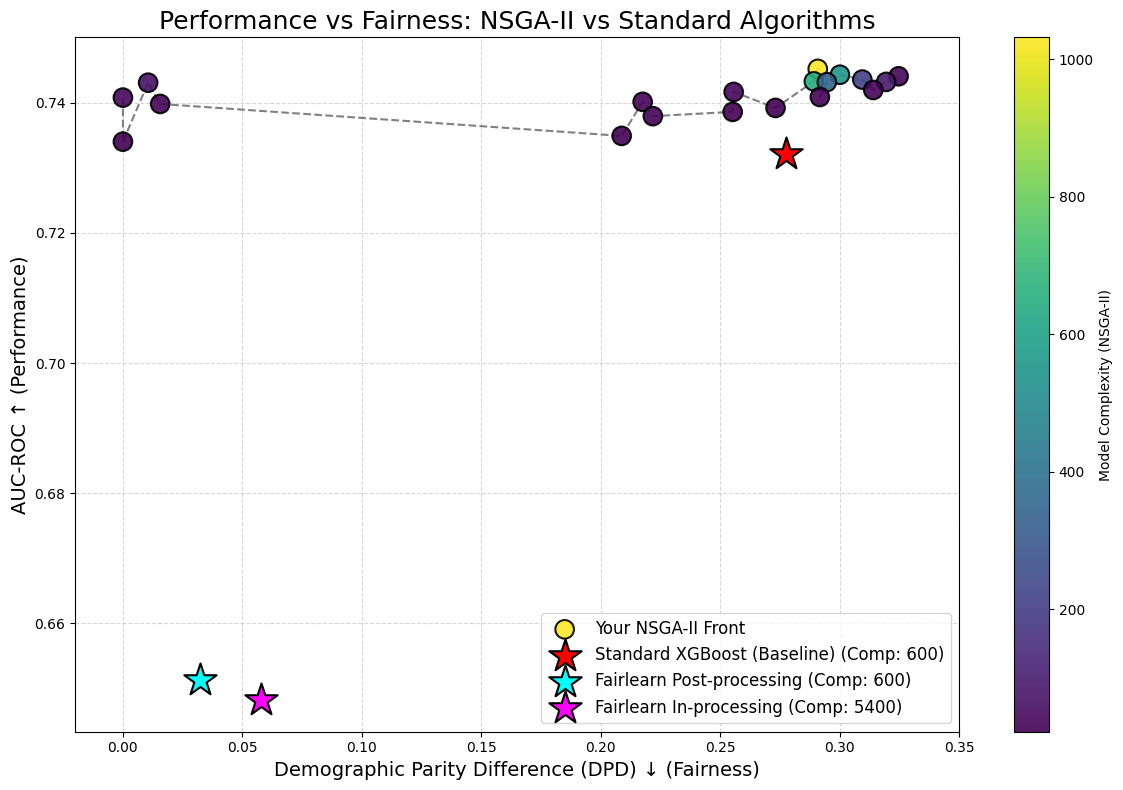

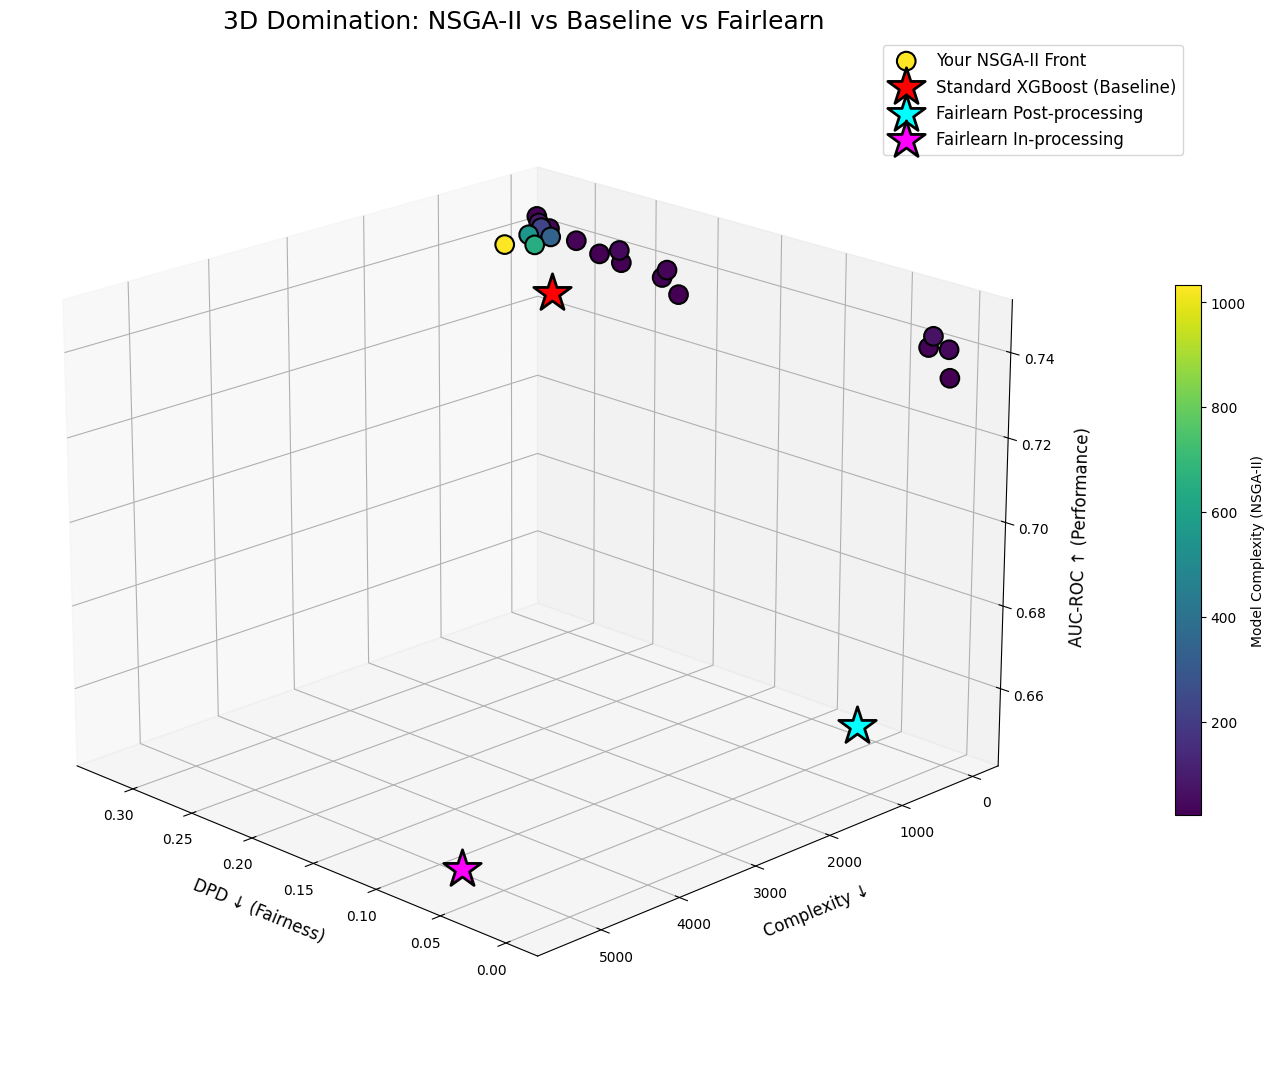

In [104]:
# ==========================================
# CELL 1: NSGA-II vs Fairlearn (2D & 3D)
# ==========================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Extract your Pareto points
p_aucs = [p['auc'] for p in pareto_points]
p_dpds = [p['dpd'] for p in pareto_points]
p_comps = [p['complexity'] for p in pareto_points]

# 2. Baseline & Fairlearn Data
fl_dpds = [0.2776, 0.0323, 0.0577]
fl_aucs = [0.7322, 0.6513, 0.6482]
fl_comps = [600, 600, 5400]
fl_labels = ['Standard XGBoost (Baseline)', 'Fairlearn Post-processing', 'Fairlearn In-processing']
fl_colors = ['red', 'cyan', 'magenta']

# ==========================================
# PLOT A: 2D AUC vs DPD Comparison
# ==========================================
plt.figure(figsize=(12, 8))

# Plot your NSGA-II Pareto Front
plt.scatter(p_dpds, p_aucs, c=p_comps, cmap='viridis', s=180, edgecolor='black', linewidth=1.5, alpha=0.9, label='Your NSGA-II Front', zorder=5)
plt.colorbar(label='Model Complexity (NSGA-II)')

# Draw a line connecting the Pareto points to emphasize the 'Frontier' curve
sorted_indices = np.argsort(p_dpds)
plt.plot(np.array(p_dpds)[sorted_indices], np.array(p_aucs)[sorted_indices], color='gray', linestyle='--', zorder=4)

# Plot Competitors as Giant Stars
for dpd, auc, comp, label, color in zip(fl_dpds, fl_aucs, fl_comps, fl_labels, fl_colors):
    plt.scatter(dpd, auc, color=color, marker='*', s=600, edgecolor='black', linewidth=1.5, label=f"{label} (Comp: {comp})", zorder=10)

plt.xlabel('Demographic Parity Difference (DPD) ↓ (Fairness)', fontsize=14)
plt.ylabel('AUC-ROC ↑ (Performance)', fontsize=14)
plt.title('Performance vs Fairness: NSGA-II vs Standard Algorithms', fontsize=18)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.02, 0.35) 
plt.tight_layout()
plt.show()


# ==========================================
# PLOT B: 3D "MIC DROP" Comparison
# ==========================================
fig_3d = plt.figure(figsize=(14, 11))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Plot your NSGA-II Pareto Front in 3D
scatter_3d = ax_3d.scatter(p_dpds, p_comps, p_aucs, c=p_comps, cmap='viridis', s=180, edgecolor='black', linewidth=1.5, alpha=1.0, label='Your NSGA-II Front', zorder=5)

# Plot Competitors as Giant Stars in 3D
for dpd, auc, comp, label, color in zip(fl_dpds, fl_aucs, fl_comps, fl_labels, fl_colors):
    # We add a thick edge to the stars so they pop out in 3D space
    ax_3d.scatter(dpd, comp, auc, color=color, marker='*', s=800, edgecolor='black', linewidth=2, label=f"{label}", zorder=10)

fig_3d.colorbar(scatter_3d, ax=ax_3d, label='Model Complexity (NSGA-II)', shrink=0.5, pad=0.1)

ax_3d.set_xlabel('DPD ↓ (Fairness)', fontsize=12, labelpad=10)
ax_3d.set_ylabel('Complexity ↓', fontsize=12, labelpad=10)
ax_3d.set_zlabel('AUC-ROC ↑ (Performance)', fontsize=12, labelpad=10)
ax_3d.set_title('3D Domination: NSGA-II vs Baseline vs Fairlearn', fontsize=18)

# Add Legend outside the plot area
ax_3d.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), fontsize=12)

# Adjust viewing angle so the massive complexity of Fairlearn (5400) is visible but doesn't obscure the front
ax_3d.view_init(elev=20, azim=135)

plt.tight_layout()
plt.show()

# Feature Importance Shift

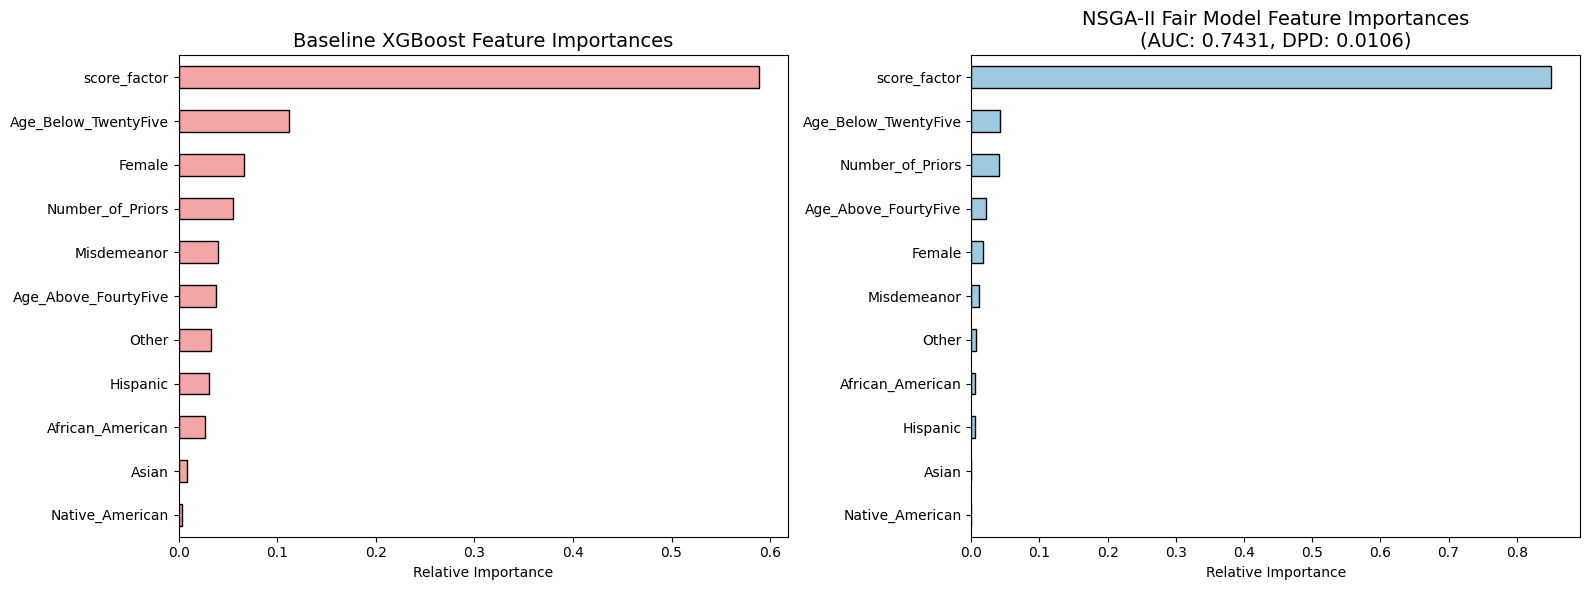

In [105]:
# ==========================================
# CELL 2: Feature Importance Analysis
# ==========================================
import pandas as pd
import xgboost as xgb

# 1. Train the Standard Unconstrained Baseline
baseline_model = xgb.XGBClassifier(random_state=42)
baseline_model.fit(X_train_full, y_train_full)

# 2. Extract your "Best Compromise" model (Model 8 from your text: strict fairness & high AUC)
# We find the point in your pareto list with DPD < 0.02 and the absolute highest AUC
best_fair_point = max([p for p in pareto_points if p['dpd'] <= 0.02], key=lambda x: x['auc'])
best_params = best_fair_point['params']

# 3. Train your NSGA-II Best Model
fair_model = xgb.XGBClassifier(**best_params, objective='binary:logistic', random_state=42)
fair_model.fit(X_train_full, y_train_full)

# 4. Plot Side-by-Side Importances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline Importances
pd.Series(baseline_model.feature_importances_, index=X_train_full.columns).sort_values(ascending=True).tail(15).plot.barh(ax=axes[0], color='#f4a6a6', edgecolor='black')
axes[0].set_title('Baseline XGBoost Feature Importances', fontsize=14)
axes[0].set_xlabel('Relative Importance')

# Fair Model Importances
pd.Series(fair_model.feature_importances_, index=X_train_full.columns).sort_values(ascending=True).tail(15).plot.barh(ax=axes[1], color='#9ecae1', edgecolor='black')
axes[1].set_title(f'NSGA-II Fair Model Feature Importances\n(AUC: {best_fair_point["auc"]:.4f}, DPD: {best_fair_point["dpd"]:.4f})', fontsize=14)
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

# Deep Fairness Analysis (Equalised odds/FPR)

In [106]:
# ==========================================
# CELL 3: False Positive / False Negative Disparity
# ==========================================
from sklearn.metrics import confusion_matrix

def calculate_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) # False Positive Rate
    fnr = fn / (fn + tp) # False Negative Rate
    return fpr, fnr

# 1. Get Predictions for Both Models on Test Set
preds_base_bin = baseline_model.predict(X_test)
preds_fair_proba = fair_model.predict_proba(X_test)[:, 1]
preds_fair_bin = (preds_fair_proba >= 0.5).astype(int)

# 2. Create Demographic Masks (assuming 1 = African American, 0 = Other)
mask_aa = (sensitive_test == 1)
mask_other = (sensitive_test == 0)

# 3. Calculate Rates
fpr_base_aa, fnr_base_aa = calculate_rates(y_test[mask_aa], preds_base_bin[mask_aa])
fpr_base_other, fnr_base_other = calculate_rates(y_test[mask_other], preds_base_bin[mask_other])

fpr_fair_aa, fnr_fair_aa = calculate_rates(y_test[mask_aa], preds_fair_bin[mask_aa])
fpr_fair_other, fnr_fair_other = calculate_rates(y_test[mask_other], preds_fair_bin[mask_other])

# 4. Print the Report
print("==========================================================")
print("             DEEP FAIRNESS ANALYSIS (FPR / FNR)           ")
print("==========================================================\n")

print("--- FALSE POSITIVE RATE (FPR) ---")
print("Metric: Innocent people incorrectly classified as high-risk (Lower is better)\n")
print("BASELINE XGBOOST:")
print(f"  African American FPR: {fpr_base_aa:.3f}")
print(f"  Other FPR:            {fpr_base_other:.3f}")
print(f"  --> Disparity Gap:    {abs(fpr_base_aa - fpr_base_other):.3f}\n")

print("YOUR NSGA-II MODEL:")
print(f"  African American FPR: {fpr_fair_aa:.3f}")
print(f"  Other FPR:            {fpr_fair_other:.3f}")
print(f"  --> Disparity Gap:    {abs(fpr_fair_aa - fpr_fair_other):.3f}\n")

print("----------------------------------------------------------")
print("--- FALSE NEGATIVE RATE (FNR) ---")
print("Metric: High-risk people incorrectly classified as low-risk (Lower is better)\n")
print("BASELINE XGBOOST:")
print(f"  African American FNR: {fnr_base_aa:.3f}")
print(f"  Other FNR:            {fnr_base_other:.3f}")
print(f"  --> Disparity Gap:    {abs(fnr_base_aa - fnr_base_other):.3f}\n")

print("YOUR NSGA-II MODEL:")
print(f"  African American FNR: {fnr_fair_aa:.3f}")
print(f"  Other FNR:            {fnr_fair_other:.3f}")
print(f"  --> Disparity Gap:    {abs(fnr_fair_aa - fnr_fair_other):.3f}\n")
print("==========================================================")

             DEEP FAIRNESS ANALYSIS (FPR / FNR)           

--- FALSE POSITIVE RATE (FPR) ---
Metric: Innocent people incorrectly classified as high-risk (Lower is better)

BASELINE XGBOOST:
  African American FPR: 0.332
  Other FPR:            0.138
  --> Disparity Gap:    0.194

YOUR NSGA-II MODEL:
  African American FPR: 0.013
  Other FPR:            0.000
  --> Disparity Gap:    0.013

----------------------------------------------------------
--- FALSE NEGATIVE RATE (FNR) ---
Metric: High-risk people incorrectly classified as low-risk (Lower is better)

BASELINE XGBOOST:
  African American FNR: 0.323
  Other FNR:            0.604
  --> Disparity Gap:    0.281

YOUR NSGA-II MODEL:
  African American FNR: 0.982
  Other FNR:            0.987
  --> Disparity Gap:    0.004



# NELDER-MEADS ALGORITHM

#  Define Nelder-Mead Objective and Execution

In [107]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings('ignore') # Suppress SciPy precision warnings

def decode_nm_x(x):
    """
    Safely clips and rounds continuous Nelder-Mead variables into valid XGBoost hyperparameters.
    """
    return {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': int(np.clip(np.round(x[0]), 10, 200)),
        'learning_rate': float(np.clip(x[1], 0.01, 0.2)),
        'max_depth': int(np.clip(np.round(x[2]), 2, 8)),
        'subsample': float(np.clip(x[3], 0.6, 1.0)),
        'colsample_bytree': float(np.clip(x[4], 0.6, 1.0)),
        'gamma': float(np.clip(x[5], 0.0, 0.5)),
        'min_child_weight': int(np.clip(np.round(x[6]), 1, 10)),
        'reg_alpha': float(np.clip(x[7], 1e-8, 1.0)),
        'reg_lambda': float(np.clip(x[8], 1e-8, 1.0)),
        'random_state': 42
    }

def nm_objective(x, w_auc, w_dpd, w_comp, X_train, y_train, X_val, y_val, sensitive_val):
    params = decode_nm_x(x)
    
    # Train Model
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)
    
    # Predict on Validation Set
    preds_proba = model.predict_proba(X_val)[:, 1]
    preds_bin = (preds_proba > 0.5).astype(int)
    
    # Calculate Raw Objectives
    auc_val = roc_auc_score(y_val, preds_proba)
    dpd_val = demographic_parity_difference(y_val, preds_bin, sensitive_val)
    comp_val = calculate_complexity(params)
    
    # Normalize objectives to roughly [0, 1] range
    norm_auc = 1.0 - auc_val             # MINIMIZE (1 - AUC)
    norm_dpd = dpd_val                   # MINIMIZE DPD
    norm_comp = comp_val / 1600.0        # MINIMIZE Complexity
    
    # Scalarization
    scalar_obj = (w_auc * norm_auc) + (w_dpd * norm_dpd) + (w_comp * norm_comp)
    return scalar_obj

def filter_non_dominated_points(points):
    """Filters a list of point dictionaries to find the 3D Pareto frontier."""
    non_dominated = []
    for i, p_i in enumerate(points):
        is_dominated = False
        for j, p_j in enumerate(points):
            if i == j: continue
            # We want to MAXIMIZE AUC, MINIMIZE DPD, MINIMIZE Complexity
            better_auc = p_j['auc'] >= p_i['auc']
            better_dpd = p_j['dpd'] <= p_i['dpd']
            better_comp = p_j['complexity'] <= p_i['complexity']
            
            strictly_better_auc = p_j['auc'] > p_i['auc']
            strictly_better_dpd = p_j['dpd'] < p_i['dpd']
            strictly_better_comp = p_j['complexity'] < p_i['complexity']
            
            if (better_auc and better_dpd and better_comp) and (strictly_better_auc or strictly_better_dpd or strictly_better_comp):
                is_dominated = True
                break
        if not is_dominated:
            non_dominated.append(p_i)
    return non_dominated

def execute_nelder_mead_search(max_evals=20, step_size=0.2):
    X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=123, stratify=y_train_full
    )
    sensitive_val_opt = X_val_opt['African_American']
    
    candidate_points = []
    
    alphas = np.arange(0.0, 1.01, step_size)
    betas = np.arange(0.0, 1.01, step_size)
    weight_pairs = [(a, b) for a in alphas for b in betas if (a + b) <= 1.0001]
    
    print(f"Total weight combinations to test: {len(weight_pairs)}")
    print(f"Max evaluations per combination: {max_evals}")
    print(f"Maximum XGBoost models to train: {len(weight_pairs) * max_evals}...\n")
    
    # Provide a reasonable initial guess for Nelder-Mead's starting simplex
    x0 = [100, 0.1, 5, 0.8, 0.8, 0.25, 5, 0.5, 0.5] 
    
    for idx, (alpha, beta) in enumerate(weight_pairs):
        gamma = max(0.0, 1.0 - alpha - beta)
        print(f"[{idx+1}/{len(weight_pairs)}] Running Nelder-Mead for Weights -> AUC: {alpha:.2f}, DPD: {beta:.2f}, Comp: {gamma:.2f}")
        
        # Optimize using SciPy's Nelder-Mead
        res = minimize(
            nm_objective, 
            x0, 
            args=(alpha, beta, gamma, X_train_opt, y_train_opt, X_val_opt, y_val_opt, sensitive_val_opt),
            method='Nelder-Mead',
            options={'maxfev': max_evals, 'disp': False}
        )
        
        # Get best parameters for this weight combination
        best_params = decode_nm_x(res.x)
        
        # Retrain on full train and evaluate on true TEST set
        final_model = xgb.XGBClassifier(**best_params)
        final_model.fit(X_train_full, y_train_full, verbose=False)
        
        preds_proba_test = final_model.predict_proba(X_test)[:, 1]
        preds_bin_test = (preds_proba_test > 0.5).astype(int)
        
        auc_test = roc_auc_score(y_test, preds_proba_test)
        dpd_test = demographic_parity_difference(y_test, preds_bin_test, sensitive_test)
        comp_test = calculate_complexity(best_params)
        
        candidate_points.append({
            'auc': auc_test, 'dpd': dpd_test, 'complexity': comp_test,
            'alpha': alpha, 'beta': beta, 'gamma': gamma, 'params': best_params
        })
        
    non_dominated = filter_non_dominated_points(candidate_points)
    print(f"\nNelder-Mead complete. Found {len(non_dominated)} non-dominated points out of {len(candidate_points)} candidates.")
    return candidate_points, non_dominated

# Execute search
nm_all_points, nm_pareto_points = execute_nelder_mead_search(max_evals=20, step_size=0.1)

Total weight combinations to test: 66
Max evaluations per combination: 20
Maximum XGBoost models to train: 1320...

[1/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.00, Comp: 1.00
[2/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.10, Comp: 0.90
[3/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.20, Comp: 0.80
[4/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.30, Comp: 0.70
[5/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.40, Comp: 0.60
[6/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.50, Comp: 0.50
[7/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.60, Comp: 0.40
[8/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.70, Comp: 0.30
[9/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.80, Comp: 0.20
[10/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 0.90, Comp: 0.10
[11/66] Running Nelder-Mead for Weights -> AUC: 0.00, DPD: 1.00, Comp: 0.00
[12/66] Running Nelder-Mead for Weights -> AUC: 0.10, DPD

In [108]:
# Create a unique string representation of the parameters to filter out exact duplicates
unique_pareto_points = []
seen_params = set()

for p in nm_pareto_points:
    param_str = str(p['params'])
    if param_str not in seen_params:
        unique_pareto_points.append(p)
        seen_params.add(param_str)

nm_pareto_points = unique_pareto_points

print(f"After removing exact duplicates, Nelder-Mead found {len(nm_pareto_points)} UNIQUE non-dominated points.")

After removing exact duplicates, Nelder-Mead found 8 UNIQUE non-dominated points.


# Plotting functions

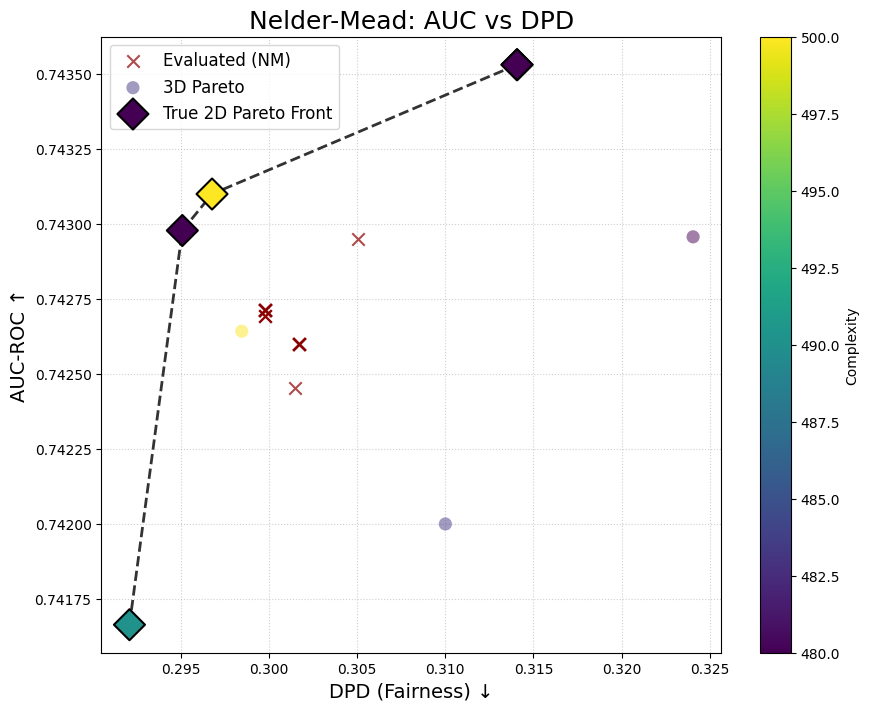

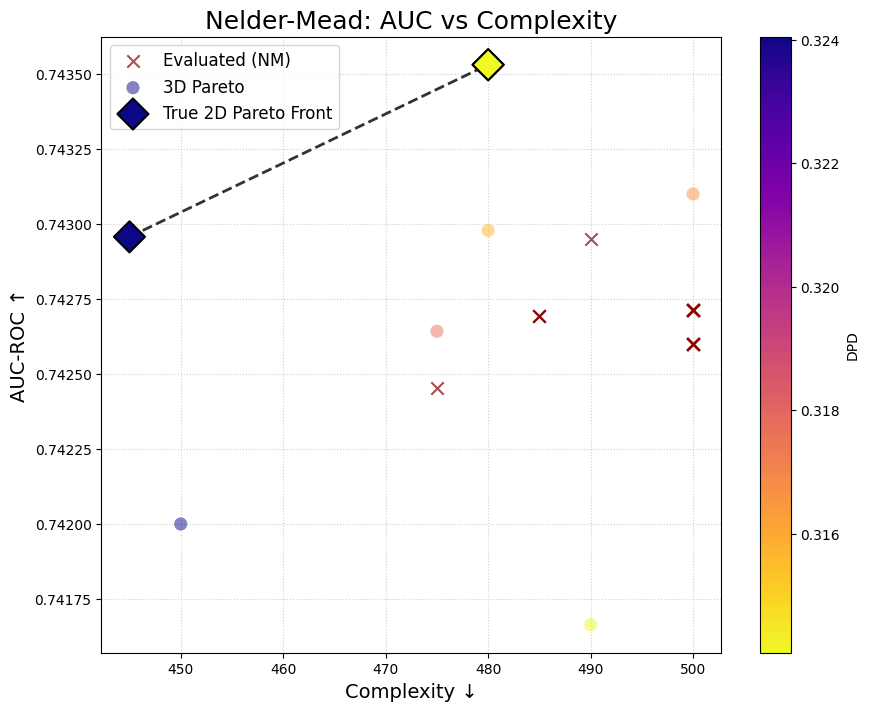

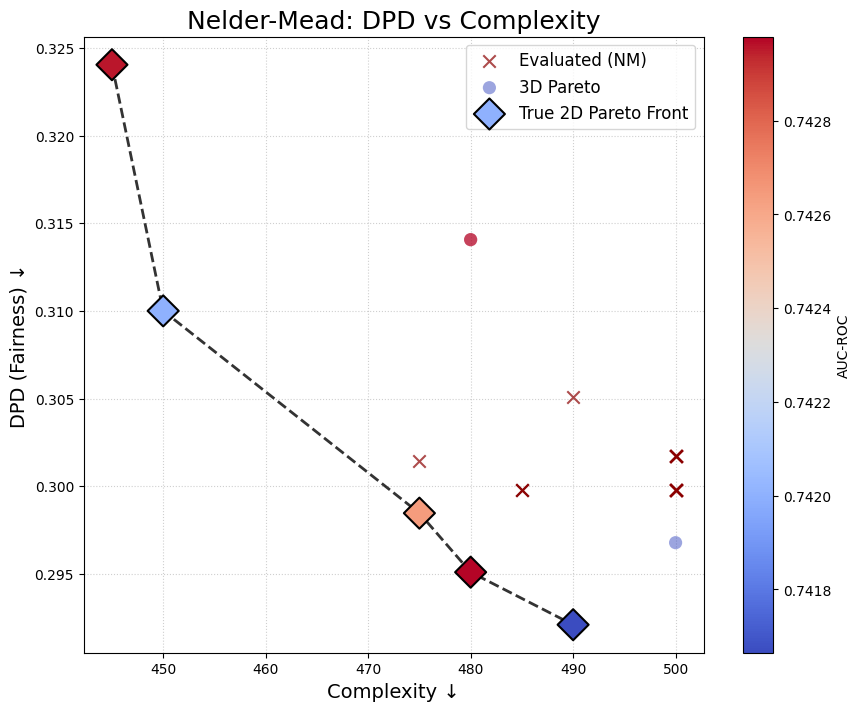

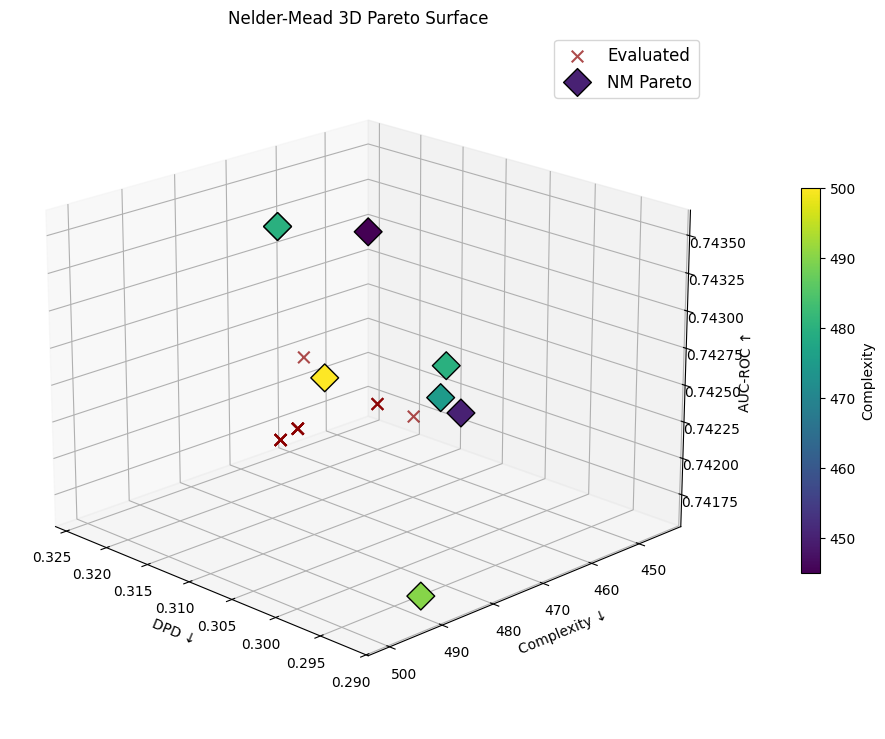

In [109]:
import matplotlib.pyplot as plt
import numpy as np

def plot_nm_frontiers(nm_all_points, nm_pareto_points):
    if not nm_all_points:
        return
        
    pareto_ids = {str(p['params']) for p in nm_pareto_points}
    dom_points = [p for p in nm_all_points if str(p['params']) not in pareto_ids]
    
    d_aucs, d_dpds, d_comps = [p['auc'] for p in dom_points], [p['dpd'] for p in dom_points], [p['complexity'] for p in dom_points]
    p_aucs, p_dpds, p_comps = [p['auc'] for p in nm_pareto_points], [p['dpd'] for p in nm_pareto_points], [p['complexity'] for p in nm_pareto_points]
    
    # --- UPDATED: Dark red and higher opacity for evaluated/dominated points ---
    dom_color = 'darkred' 
    dom_alpha = 0.7 

    def get_2d_pareto(xs, ys, min_x=True, min_y=False):
        pareto_idx = []
        for i in range(len(xs)):
            is_dominated = False
            for j in range(len(xs)):
                if i == j: continue
                better_x = xs[j] < xs[i] if min_x else xs[j] > xs[i]
                better_y = ys[j] < ys[i] if min_y else ys[j] > ys[i]
                if (better_x or xs[j]==xs[i]) and (better_y or ys[j]==ys[i]) and (better_x or better_y):
                    is_dominated = True; break
            if not is_dominated: pareto_idx.append(i)
        return pareto_idx

    def make_2d_layered_plot(x_dom, y_dom, x_par, y_par, c_par, min_x, min_y, cmap_par, cbar_label, xlabel, ylabel, title):
        idx_2d = get_2d_pareto(x_par, y_par, min_x, min_y)
        x_2d_front, y_2d_front, c_2d_front = [x_par[i] for i in idx_2d], [y_par[i] for i in idx_2d], [c_par[i] for i in idx_2d]
        x_3d_only, y_3d_only, c_3d_only = [x_par[i] for i in range(len(x_par)) if i not in idx_2d], [y_par[i] for i in range(len(y_par)) if i not in idx_2d], [c_par[i] for i in range(len(c_par)) if i not in idx_2d]
        
        plt.figure(figsize=(10, 8))
        
        # Plot dominated points with dark red crosses
        plt.scatter(x_dom, y_dom, c=dom_color, marker='x', s=80, alpha=dom_alpha, label='Evaluated (NM)', zorder=3)
        plt.scatter(x_3d_only, y_3d_only, c=c_3d_only, cmap=cmap_par, s=90, alpha=0.5, edgecolors='none', label='3D Pareto', zorder=4)

        if len(x_2d_front) > 0:
            sorted_idx = np.argsort(x_2d_front)
            plt.plot(np.array(x_2d_front)[sorted_idx], np.array(y_2d_front)[sorted_idx], color='black', linestyle='--', linewidth=2.0, alpha=0.8, zorder=5)

        scatter = plt.scatter(x_2d_front, y_2d_front, c=c_2d_front, cmap=cmap_par, s=250, marker='D', edgecolors='black', linewidth=1.5, alpha=1.0, label='True 2D Pareto Front', zorder=6)
        
        plt.xlabel(xlabel, fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        plt.title(title, fontsize=18)
        plt.colorbar(scatter, label=cbar_label)
        plt.legend(loc='best', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

    # Render Plots
    make_2d_layered_plot(d_dpds, d_aucs, p_dpds, p_aucs, p_comps, True, False, 'viridis', 'Complexity', 'DPD (Fairness) ↓', 'AUC-ROC ↑', 'Nelder-Mead: AUC vs DPD')
    make_2d_layered_plot(d_comps, d_aucs, p_comps, p_aucs, p_dpds, True, False, 'plasma_r', 'DPD', 'Complexity ↓', 'AUC-ROC ↑', 'Nelder-Mead: AUC vs Complexity')
    make_2d_layered_plot(d_comps, d_dpds, p_comps, p_dpds, p_aucs, True, True, 'coolwarm', 'AUC-ROC', 'Complexity ↓', 'DPD (Fairness) ↓', 'Nelder-Mead: DPD vs Complexity')

    # 3D Plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    # Plot dominated points with dark red crosses in 3D
    ax.scatter(d_dpds, d_comps, d_aucs, c=dom_color, marker='x', s=70, alpha=dom_alpha, label='Evaluated')
    scatter = ax.scatter(p_dpds, p_comps, p_aucs, c=p_comps, cmap='viridis', s=200, marker='D', edgecolors='black', alpha=1.0, label='NM Pareto', zorder=5)
    fig.colorbar(scatter, ax=ax, label='Complexity', shrink=0.5, pad=0.1)
    ax.set(xlabel='DPD ↓', ylabel='Complexity ↓', zlabel='AUC-ROC ↑', title='Nelder-Mead 3D Pareto Surface')
    ax.view_init(elev=20, azim=135)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

# Run the plot
plot_nm_frontiers(nm_all_points, nm_pareto_points)

# Save Nelder-Mead Results to CSV

In [110]:
# Convert Nelder-Mead Pareto points to DataFrame and save to CSV
nm_pareto_df = pd.DataFrame([{
    'Model_ID': f"NM_Model_{i+1}",
    'AUC-ROC (Max)': p['auc'],
    'DPD (Min)': p['dpd'],
    'Complexity (Min)': p['complexity'],
    'Weight_AUC': p['alpha'],
    'Weight_DPD': p['beta'],
    'Weight_Comp': p['gamma'],
    'Params': str(p['params'])
} for i, p in enumerate(nm_pareto_points)])

nm_pareto_df.to_csv("nelder_mead_pareto_front.csv", index=False)
display(nm_pareto_df.head())

,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min),Weight_AUC,Weight_DPD,Weight_Comp,Params
0,NM_Model_1,0.742001,0.310006,450,0.0,0.0,1.0,"{'objective': 'binary:logistic', 'eval_metric'..."
1,NM_Model_2,0.742958,0.324046,445,0.0,0.4,0.6,"{'objective': 'binary:logistic', 'eval_metric'..."
2,NM_Model_3,0.742979,0.295101,480,0.0,0.6,0.4,"{'objective': 'binary:logistic', 'eval_metric'..."
3,NM_Model_4,0.743101,0.296785,500,0.0,1.0,0.0,"{'objective': 'binary:logistic', 'eval_metric'..."
4,NM_Model_5,0.743532,0.314069,480,0.1,0.5,0.4,"{'objective': 'binary:logistic', 'eval_metric'..."


# Calculate Nelder-Mead Utopia Point and Distance

In [111]:
# 1. Identify the Utopia Point coordinates
utopia_auc_nm = nm_pareto_df['AUC-ROC (Max)'].max()
utopia_dpd_nm = nm_pareto_df['DPD (Min)'].min()
utopia_comp_nm = nm_pareto_df['Complexity (Min)'].min()

print("--- NELDER-MEAD UTOPIA POINT ---")
print(f"- AUC-ROC: {utopia_auc_nm:.4f}")
print(f"- DPD: {utopia_dpd_nm:.4f}")
print(f"- Complexity: {utopia_comp_nm}")

# 2. Normalize metrics
auc_min_nm = nm_pareto_df['AUC-ROC (Max)'].min()
dpd_max_nm = nm_pareto_df['DPD (Min)'].max()
comp_max_nm = nm_pareto_df['Complexity (Min)'].max()

auc_range_nm = (utopia_auc_nm - auc_min_nm) if (utopia_auc_nm - auc_min_nm) > 0 else 1.0
dpd_range_nm = (dpd_max_nm - utopia_dpd_nm) if (dpd_max_nm - utopia_dpd_nm) > 0 else 1.0
comp_range_nm = (comp_max_nm - utopia_comp_nm) if (comp_max_nm - utopia_comp_nm) > 0 else 1.0

norm_auc_nm = (utopia_auc_nm - nm_pareto_df['AUC-ROC (Max)']) / auc_range_nm
norm_dpd_nm = (nm_pareto_df['DPD (Min)'] - utopia_dpd_nm) / dpd_range_nm
norm_comp_nm = (nm_pareto_df['Complexity (Min)'] - utopia_comp_nm) / comp_range_nm

# 3. Distance to normalized utopia
nm_pareto_df['Utopia_Distance'] = np.sqrt(norm_auc_nm**2 + norm_dpd_nm**2 + norm_comp_nm**2)
nm_eval = nm_pareto_df.sort_values(by='Utopia_Distance').reset_index(drop=True)

print("\nBEST OVERALL COMPROMISE (Nelder-Mead)")
display(nm_eval[['Model_ID', 'AUC-ROC (Max)', 'DPD (Min)', 'Complexity (Min)', 'Utopia_Distance']].head(1))

--- NELDER-MEAD UTOPIA POINT ---
- AUC-ROC: 0.7435
- DPD: 0.2921
- Complexity: 445

BEST OVERALL COMPROMISE (Nelder-Mead)


,Model_ID,AUC-ROC (Max),DPD (Min),Complexity (Min),Utopia_Distance
0,NM_Model_3,0.742979,0.295101,480,0.708093


# Comparison of Both Search Algorithms

In [112]:
import numpy as np
import pandas as pd

try:
    # ---------------------------------------------------------
    # 1. Calculate Utopia distances for NSGA-II (pareto_df)
    # ---------------------------------------------------------
    utopia_auc_nsga = pareto_df['AUC-ROC (Max)'].max()
    utopia_dpd_nsga = pareto_df['DPD (Min)'].min()
    utopia_comp_nsga = pareto_df['Complexity (Min)'].min()

    # Ranges for normalization to prevent scale dominance
    auc_range_nsga = (utopia_auc_nsga - pareto_df['AUC-ROC (Max)'].min()) or 1.0
    dpd_range_nsga = (pareto_df['DPD (Min)'].max() - utopia_dpd_nsga) or 1.0
    comp_range_nsga = (pareto_df['Complexity (Min)'].max() - utopia_comp_nsga) or 1.0

    # Calculate normalized distances
    norm_auc_nsga = (utopia_auc_nsga - pareto_df['AUC-ROC (Max)']) / auc_range_nsga
    norm_dpd_nsga = (pareto_df['DPD (Min)'] - utopia_dpd_nsga) / dpd_range_nsga
    norm_comp_nsga = (pareto_df['Complexity (Min)'] - utopia_comp_nsga) / comp_range_nsga

    pareto_df['Utopia_Distance'] = np.sqrt(norm_auc_nsga**2 + norm_dpd_nsga**2 + norm_comp_nsga**2)
    
    # Sort to find the best NSGA-II compromise
    nsga_eval = pareto_df.sort_values(by='Utopia_Distance').reset_index(drop=True)
    nsga_best = nsga_eval.iloc[0]

    # ---------------------------------------------------------
    # 2. Extract best Nelder-Mead compromise (from Cell 4)
    # ---------------------------------------------------------
    nm_best = nm_eval.iloc[0]    
    
    # ---------------------------------------------------------
    # 3. Create Comparison Table
    # ---------------------------------------------------------
    comparison_df = pd.DataFrame({
        'Algorithm': ['NSGA-II (Evolutionary)', 'Nelder-Mead (Scalarized)'],
        'Best Model ID': [nsga_best['Model_ID'], nm_best['Model_ID']],
        'AUC-ROC': [nsga_best['AUC-ROC (Max)'], nm_best['AUC-ROC (Max)']],
        'DPD': [nsga_best['DPD (Min)'], nm_best['DPD (Min)']],
        'Complexity': [nsga_best['Complexity (Min)'], nm_best['Complexity (Min)']],
        'Distance to Own Utopia': [nsga_best['Utopia_Distance'], nm_best['Utopia_Distance']]
    })
    
    print("--- ALGORITHM COMPARISON: BEST COMPROMISE MODELS ---")
    display(comparison_df.set_index('Algorithm'))
    
except NameError as e:
    print(f"Error: {e}")
    print("Make sure you have run the NSGA-II cell that creates `pareto_df` and the Nelder-Mead Cell 4 that creates `nm_eval`.")

--- ALGORITHM COMPARISON: BEST COMPROMISE MODELS ---


,Best Model ID,AUC-ROC,DPD,Complexity,Distance to Own Utopia
Algorithm,,,,,
NSGA-II (Evolutionary),Model_8,0.743100,0.010600,66,0.195243
Nelder-Mead (Scalarized),NM_Model_3,0.742979,0.295101,480,0.708093


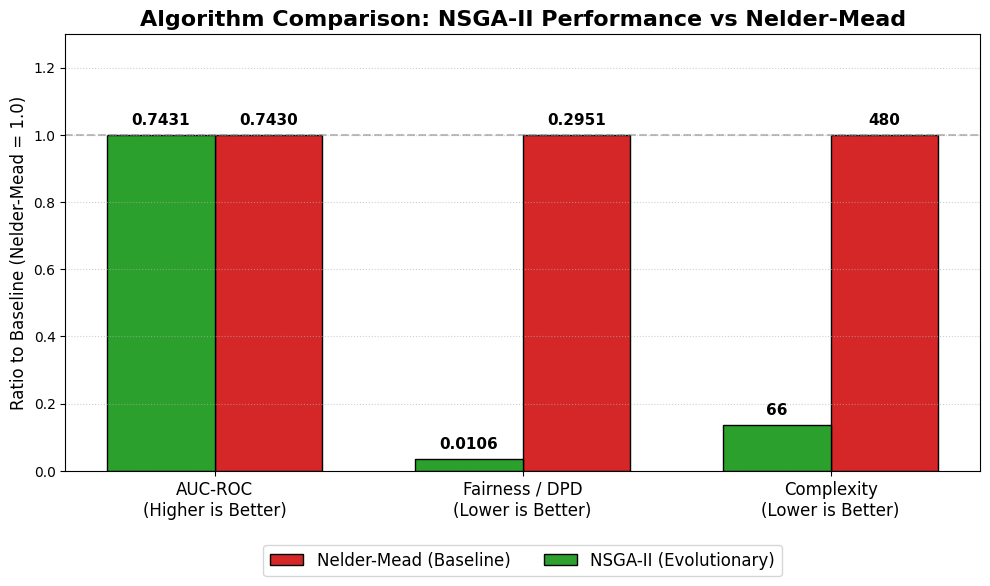

In [115]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the best models from the comparison dataframe
nsga_row = comparison_df[comparison_df['Algorithm'].str.contains('NSGA-II')].iloc[0]
nm_row = comparison_df[comparison_df['Algorithm'].str.contains('Nelder-Mead')].iloc[0]

# Raw values
nsga_vals = [nsga_row['AUC-ROC'], nsga_row['DPD'], nsga_row['Complexity']]
nm_vals = [nm_row['AUC-ROC'], nm_row['DPD'], nm_row['Complexity']]

# 2. Calculate values relative to Nelder-Mead (NM = 1.0 or 100%)
# For AUC (Higher is better)
nsga_auc_rel = nsga_vals[0] / nm_vals[0]
nm_auc_rel = 1.0

# For DPD and Complexity (Lower is better, so we just show the raw ratio)
nsga_dpd_rel = nsga_vals[1] / nm_vals[1]
nm_dpd_rel = 1.0

nsga_comp_rel = nsga_vals[2] / nm_vals[2]
nm_comp_rel = 1.0

nsga_rel_vals = [nsga_auc_rel, nsga_dpd_rel, nsga_comp_rel]
nm_rel_vals = [nm_auc_rel, nm_dpd_rel, nm_comp_rel]

# 3. Plotting
metrics = ['AUC-ROC\n(Higher is Better)', 'Fairness / DPD\n(Lower is Better)', 'Complexity\n(Lower is Better)']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Nelder-Mead is the baseline (all bars are at 1.0)
rects2 = ax.bar(x + width/2, nm_rel_vals, width, label='Nelder-Mead (Baseline)', color='#d62728', edgecolor='black', linewidth=1)
# NSGA-II shows its ratio relative to Nelder Mead
rects1 = ax.bar(x - width/2, nsga_rel_vals, width, label='NSGA-II (Evolutionary)', color='#2ca02c', edgecolor='black', linewidth=1)

ax.set_ylabel('Ratio to Baseline (Nelder-Mead = 1.0)', fontsize=12)
ax.set_title('Algorithm Comparison: NSGA-II Performance vs Nelder-Mead', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)

# Draw a dashed line at 1.0 to show the baseline clearly
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Move legend outside
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12)

# Add raw values as text on top of the bars so the user knows the actual numbers
def autolabel(rects, raw_vals, is_float):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        val_str = f"{raw_vals[i]:.4f}" if is_float[i] else f"{int(raw_vals[i])}"
        ax.annotate(val_str,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1, nsga_vals, [True, True, False])
autolabel(rects2, nm_vals, [True, True, False])

plt.ylim(0, 1.3) # Set y-limit slightly above 1.0
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()